## Apply AIMS4PT Cpx to Merapi

This notebook applies the AIMS4PT clinopyroxene thermobarometry workflow to the Merapi case study, including data preparation, P-T calculation, equilibrium checks, and figure export.


## 1. Setup and Shared Model Pools

### Module and Data Imports

In [39]:
%matplotlib inline

from pathlib import Path
import sys

def _find_project_root(start=None):
    """Find the project root by walking upward from the current directory."""
    path = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (path, *path.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find pyproject.toml above the current directory.")

PROJECT_ROOT = _find_project_root()
PAPER_DIR = PROJECT_ROOT / "paper"
CACHE_DIR = PAPER_DIR / ".cache"
IMAGES_DIR = PAPER_DIR / ".images"
DATA_DIR = PAPER_DIR / "data"
for _dir in (CACHE_DIR, IMAGES_DIR, DATA_DIR):
    _dir.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2
# %matplotlib widget
%matplotlib inline

import pandas as pd
import numpy as np
import sys
import os
import time
import importlib
import matplotlib.pyplot as plt
from aims4pt.model_tools.model_registry import  get_models_initial_pools, print_all_registered_thermobarometry, ALL_MODELS_MODULES
from aims4pt.toolkit_utils import get_file_path
for module in ALL_MODELS_MODULES:
    importlib.import_module(module)



calculate_shap = False # make sure this to False when not needed, as it takes time and memory

timestamp = time.strftime("%Y%m%d_%H%M")
timestamp = "20260530_1500" 


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:


#col names for unseen_experiments_df
cpx_names = ['SiO2_cpx', 'TiO2_cpx', 'Al2O3_cpx',
       'Fe2O3_cpx', 'Cr2O3_cpx', 'FeO_cpx', 'MnO_cpx', 'MgO_cpx', 'NiO_cpx',
       'CoO_cpx', 'CaO_cpx', 'Na2O_cpx', 'K2O_cpx', 'P2O5_cpx',]
liq_names = ['SiO2_liq', 'TiO2_liq', 'Al2O3_liq',
       'Fe2O3_liq', 'Cr2O3_liq', 'FeO_liq', 'MnO_liq', 'MgO_liq', 'NiO_liq',
       'CoO_liq', 'CaO_liq', 'Na2O_liq', 'K2O_liq', 'P2O5_liq']
P_col = 'P (kbar)'
T_col = 'T (C)'


### Initial Thermobarometry Model Pools

In [41]:
P_model_pool = get_models_initial_pools("P", "both" , False) # get all P models including cpx_only and cpx_liq
P_model_names = list(model.model_name for model in P_model_pool)
T_model_pool = get_models_initial_pools("T", "both" , False) # get all T models including cpx_only and cpx_liq
T_model_names = list(model.model_name for model in T_model_pool)


[Skip] Error initializing model Brugman_Till_19: Brugman_Till_19 only supports temperature (T) calculations, not pressure (P) calculations.


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.7.2 when using ver

[Skip] Error initializing model Brugman_Till_19: Brugman_Till_19 only supports temperature (T) calculations, not pressure (P) calculations.


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.7.2 when using ver

[skipped] Error initializing model <class 'aims4pt.model_tools.Neave_Putirka_17.Neave_Putirka_17'> with T: Pu08_eq33_T, P: eq1_P - Neave_Putirka_17 only supports pressure (P) calculations, not temperature (T) calculations.


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.7.2 when using ver

In [42]:
P_model_dict = {model.model_name: model for model in P_model_pool}
T_model_dict = {model.model_name: model for model in T_model_pool}

In [43]:
unseen_experiments_df_path = os.path.join(DATA_DIR, "independent_data_final.xlsx")
unseen_experiments_df = pd.read_excel(unseen_experiments_df_path)
cpx_unseen = unseen_experiments_df[cpx_names].copy()
liq_unseen = unseen_experiments_df[liq_names].copy()
meta_unseen = unseen_experiments_df[[P_col, T_col]].copy()

testing_unseen_id = unseen_experiments_df[unseen_experiments_df["training/testing"] == "testing"].index.tolist()
training_unseen_id = unseen_experiments_df[unseen_experiments_df["training/testing"] == "training"].index.tolist()


## 2. Loading and Preparing Merapi Data

In [44]:
from aims4pt.model_tools.CpxTBSelect import workflow_thermobarometry
cpx_raw_path = os.path.join(DATA_DIR, "merapi_cpx_raw.xlsx")
liq_raw_path = os.path.join(DATA_DIR, "merapi_liq.xlsx")
cpx_raw = pd.read_excel(cpx_raw_path)
liq_raw = pd.read_excel(liq_raw_path)
cpx_raw.columns = cpx_raw.columns.str.strip()  
liq_raw.columns = liq_raw.columns.str.strip()
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
cpx_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO',
       'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', 'Cr2O3', 'NiO']
# Set water content (following Scruggs and Putirka, 2018)
# Liq_Comp['H2O_Liq']=Liq_Comp['SiO2_Liq']*0.06995+0.383
cpx_raw.keys()

Index(['Sample_id', 'Eruption', 'Source', 'Rim/core', 'SiO2', 'TiO2', 'Al2O3',
       'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', 'Cr2O3', 'NiO', 'F', 'Cl',
       'TOTAL', '(Ca+Fe+Mg)/Si', 'cpx/opx'],
      dtype='object')

### cpx clean

In [45]:
# clean cpx
print("Before cleaning, number of cpx samples:", len(cpx_raw))

# negative value to zero
cpx_raw[cpx_cols] = cpx_raw[cpx_cols].clip(lower=0)
# check if cpx
from aims4pt.data_tools.compositions import pyroxene_classification, cpx_stoichiometry_check

cpx_class = pyroxene_classification(cpx_raw[cpx_cols])
cpx_clean0 = cpx_raw[cpx_class=="Clinopyroxene"] # remove opx samples
print("After cpx classification, number of cpx samples:", len(cpx_clean0))
# total 

cpx_clean1 = cpx_clean0[
    (cpx_clean0["TOTAL"] > 98) & (cpx_clean0["TOTAL"] < 102)
].reset_index(drop=True)
print("After checking total, number of cpx samples:", len(cpx_clean1))

# '(Ca+Fe+Mg)/Si'
cpx_clean1['(Ca+Fe+Mg)/Si'], stio_mask = cpx_stoichiometry_check(cpx_clean1[cpx_cols])
cpx_clean1['(Ca+Fe+Mg)/Si'].hist()
cpx_clean2 = cpx_clean1[stio_mask].reset_index(drop=True)
print("After cpx stoichiometry check, number of cpx samples:", len(cpx_clean2))
cpx_clean2

Before cleaning, number of cpx samples: 530
After cpx classification, number of cpx samples: 518
After checking total, number of cpx samples: 480
After cpx stoichiometry check, number of cpx samples: 475


,Sample_id,Eruption,Source,Rim/core,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O,Cr2O3,NiO,F,Cl,TOTAL,(Ca+Fe+Mg)/Si,cpx/opx
0,2006px2 Line 001,2006,"Li et al., 2021",rim,50.742922,0.675655,3.419136,9.256879,0.628818,14.746829,20.014550,0.427517,0.030893,NaN,NaN,0.083710,0.009965,100.036872,1.008423,NaN
1,2006px2 Line 002,2006,"Li et al., 2021",rim,49.958897,0.932331,4.417043,8.972431,0.460150,13.695238,21.117794,0.411028,0.023058,NaN,NaN,0.012030,0.006015,100.006015,1.011768,NaN
2,2006px2 Line 003,2006,"Li et al., 2021",rim,49.069929,1.013068,5.125703,9.046187,0.412471,13.039104,21.861953,0.396374,0.022133,NaN,NaN,0.022133,0.000000,100.009054,1.027670,NaN
3,2006px2 Line 004,2006,"Li et al., 2021",rim,48.042978,1.000727,6.222483,9.638688,0.330210,12.317728,22.040231,0.383730,0.013128,NaN,NaN,0.008079,0.006059,100.004039,1.041543,NaN
4,2006px2 Line 005,2006,"Li et al., 2021",rim,49.064653,0.825188,5.260575,9.389521,0.364525,12.899575,21.785371,0.392565,0.015022,NaN,NaN,0.000000,0.004006,100.001001,1.027721,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,Un 298 2010-CpxSkull-c1,2010,LI thesis,NaN,51.953300,0.382202,1.668580,8.934350,0.767469,15.338800,20.047700,0.352465,NaN,0.000653,0.011991,NaN,NaN,99.457500,0.997407,NaN
471,Un 299 2010-CpxSkull-c2,2010,LI thesis,NaN,51.316300,0.375957,1.514440,8.941050,0.749842,15.304600,20.101100,0.364818,NaN,0.000000,0.000000,NaN,NaN,98.661900,1.010019,NaN
472,Un 300 2010-CpxSkull-Rim2,2010,LI thesis,rim,47.082500,1.297910,6.205480,9.609230,0.331092,12.300700,21.885100,0.361091,NaN,0.000000,0.003883,NaN,NaN,99.068800,1.058198,NaN
473,Un 301 2010-CpxSkull-Rim3,2010,LI thesis,rim,46.047900,1.521490,7.018780,9.964770,0.298006,11.698400,21.992200,0.357622,NaN,0.006623,0.005107,NaN,NaN,98.910900,1.071423,NaN


In [46]:
cpx_06_input = cpx_clean2[cpx_clean2["Eruption"]==2006].reset_index(drop=True)
cpx_06_input


,Sample_id,Eruption,Source,Rim/core,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O,Cr2O3,NiO,F,Cl,TOTAL,(Ca+Fe+Mg)/Si,cpx/opx
0,2006px2 Line 001,2006,"Li et al., 2021",rim,50.742922,0.675655,3.419136,9.256879,0.628818,14.746829,20.014550,0.427517,0.030893,NaN,NaN,0.083710,0.009965,100.036872,1.008423,NaN
1,2006px2 Line 002,2006,"Li et al., 2021",rim,49.958897,0.932331,4.417043,8.972431,0.460150,13.695238,21.117794,0.411028,0.023058,NaN,NaN,0.012030,0.006015,100.006015,1.011768,NaN
2,2006px2 Line 003,2006,"Li et al., 2021",rim,49.069929,1.013068,5.125703,9.046187,0.412471,13.039104,21.861953,0.396374,0.022133,NaN,NaN,0.022133,0.000000,100.009054,1.027670,NaN
3,2006px2 Line 004,2006,"Li et al., 2021",rim,48.042978,1.000727,6.222483,9.638688,0.330210,12.317728,22.040231,0.383730,0.013128,NaN,NaN,0.008079,0.006059,100.004039,1.041543,NaN
4,2006px2 Line 005,2006,"Li et al., 2021",rim,49.064653,0.825188,5.260575,9.389521,0.364525,12.899575,21.785371,0.392565,0.015022,NaN,NaN,0.000000,0.004006,100.001001,1.027721,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,Un 159 2006pair-clB-cpx-rim-W,2006,LI thesis,NaN,51.637700,0.359146,1.598750,8.708690,0.696622,15.158300,20.371000,0.390285,NaN,0.007531,0.010138,NaN,NaN,98.938200,1.001345,NaN
166,Un 160 2006pair-clB-cpx-CORE1,2006,LI thesis,NaN,51.437700,0.409381,1.926880,8.708280,0.615156,15.110400,20.188000,0.356576,NaN,0.000000,0.020000,NaN,NaN,98.765400,1.000032,NaN
167,Un 161 2006pair-clB-cpx-CORE2,2006,LI thesis,NaN,51.680400,0.338079,1.557080,9.108510,0.726193,14.964400,20.155600,0.369271,NaN,0.000000,0.000000,NaN,NaN,98.885900,0.996929,NaN
168,Un 163 2006pair-clB-cpx-99E,2006,LI thesis,NaN,51.210300,0.355892,1.568620,8.778750,0.705213,14.858700,20.290900,0.365352,NaN,0.000000,0.002530,NaN,NaN,98.129900,1.000449,NaN


In [47]:
cpx_10_input = cpx_clean2[cpx_clean2["Eruption"]==2010].reset_index(drop=True)
cpx_10_input

,Sample_id,Eruption,Source,Rim/core,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O,Cr2O3,NiO,F,Cl,TOTAL,(Ca+Fe+Mg)/Si,cpx/opx
0,2010-cpx1 Line 002,2010,"Li et al., 2021",rim,46.944338,1.620366,7.250910,10.177828,0.348012,12.059705,21.104987,0.414395,0.074430,NaN,NaN,0.000000,0.006035,100.001006,1.045983,NaN
1,2010-cpx1 Line 003,2010,"Li et al., 2021",rim,45.889246,1.790232,8.059587,10.460056,0.270205,11.393122,21.696318,0.392657,0.048576,NaN,NaN,0.000000,0.000000,100.000000,1.067328,NaN
2,2010-cpx1 Line 004,2010,"Li et al., 2021",rim,46.054772,1.771846,8.817550,10.425731,0.281584,10.557882,21.597609,0.461513,0.026430,NaN,NaN,0.009149,0.000000,100.004066,1.033536,NaN
3,2010-cpx1 Line 005,2010,"Li et al., 2021",rim,45.145040,1.826159,8.919170,10.696810,0.324146,10.854754,21.809642,0.367503,0.029937,NaN,NaN,0.043357,0.002065,100.018582,1.074221,NaN
4,2010-cpx1 Line 006,2010,"Li et al., 2021",rim,45.275865,1.719797,8.928589,10.595812,0.203221,10.994166,21.870040,0.371056,0.034376,NaN,NaN,0.004044,0.006066,100.003033,1.075271,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300,Un 298 2010-CpxSkull-c1,2010,LI thesis,NaN,51.953300,0.382202,1.668580,8.934350,0.767469,15.338800,20.047700,0.352465,NaN,0.000653,0.011991,NaN,NaN,99.457500,0.997407,NaN
301,Un 299 2010-CpxSkull-c2,2010,LI thesis,NaN,51.316300,0.375957,1.514440,8.941050,0.749842,15.304600,20.101100,0.364818,NaN,0.000000,0.000000,NaN,NaN,98.661900,1.010019,NaN
302,Un 300 2010-CpxSkull-Rim2,2010,LI thesis,rim,47.082500,1.297910,6.205480,9.609230,0.331092,12.300700,21.885100,0.361091,NaN,0.000000,0.003883,NaN,NaN,99.068800,1.058198,NaN
303,Un 301 2010-CpxSkull-Rim3,2010,LI thesis,rim,46.047900,1.521490,7.018780,9.964770,0.298006,11.698400,21.992200,0.357622,NaN,0.006623,0.005107,NaN,NaN,98.910900,1.071423,NaN


### liquid clean

Data were screened by eruption year using Tukey's criterion for Al2O3, Na2O, CaO, and MgO. Values below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR are flagged as rejected liquid analyses.


Before liquid cleaning: 18
After Tukey liquid cleaning: 13
Tukey-flagged liquid analyses: 4
Rejected liquid analyses: 5
Retained borderline Tukey-flagged analyses: 0


,Eruption,Component,Q1,Q3,IQR,Lower_bound,Upper_bound,n,n_rejected
0,2006,Al2O3,14.031,15.008,0.977,12.565,16.474,10,2
1,2006,Na2O,3.808,4.182,0.374,3.248,4.743,10,2
2,2006,CaO,0.842,1.148,0.306,0.383,1.606,10,2
3,2006,MgO,0.180,0.229,0.049,0.107,0.302,10,2
4,2010,Al2O3,14.678,14.848,0.171,14.422,15.104,8,1
5,2010,Na2O,3.723,3.922,0.199,3.425,4.221,8,2
6,2010,CaO,1.119,1.378,0.259,0.731,1.767,8,1
7,2010,MgO,0.352,0.666,0.314,-0.119,1.137,8,0


,Sample_id,Eruption,Source,glass/bulk,Tukey_flagged_components,Tukey_retained_override,Al2O3,Na2O,CaO,MgO
8,06_matrix1_g1,2006,"Li et al., 2021",glass,"Al2O3, Na2O, CaO",False,17.704,5.162,2.533,0.141
9,06_matrix1_g2,2006,"Li et al., 2021",glass,"Al2O3, Na2O, CaO, MgO",False,19.219,5.766,3.191,0.080
16,06_matrix1_g9,2006,"Li et al., 2021",glass,MgO,False,13.122,3.366,0.929,0.981
6,oct10_matrix1_gl8,2010,"Li et al., 2021",glass,"Al2O3, Na2O, CaO",False,17.155,4.708,2.911,0.823


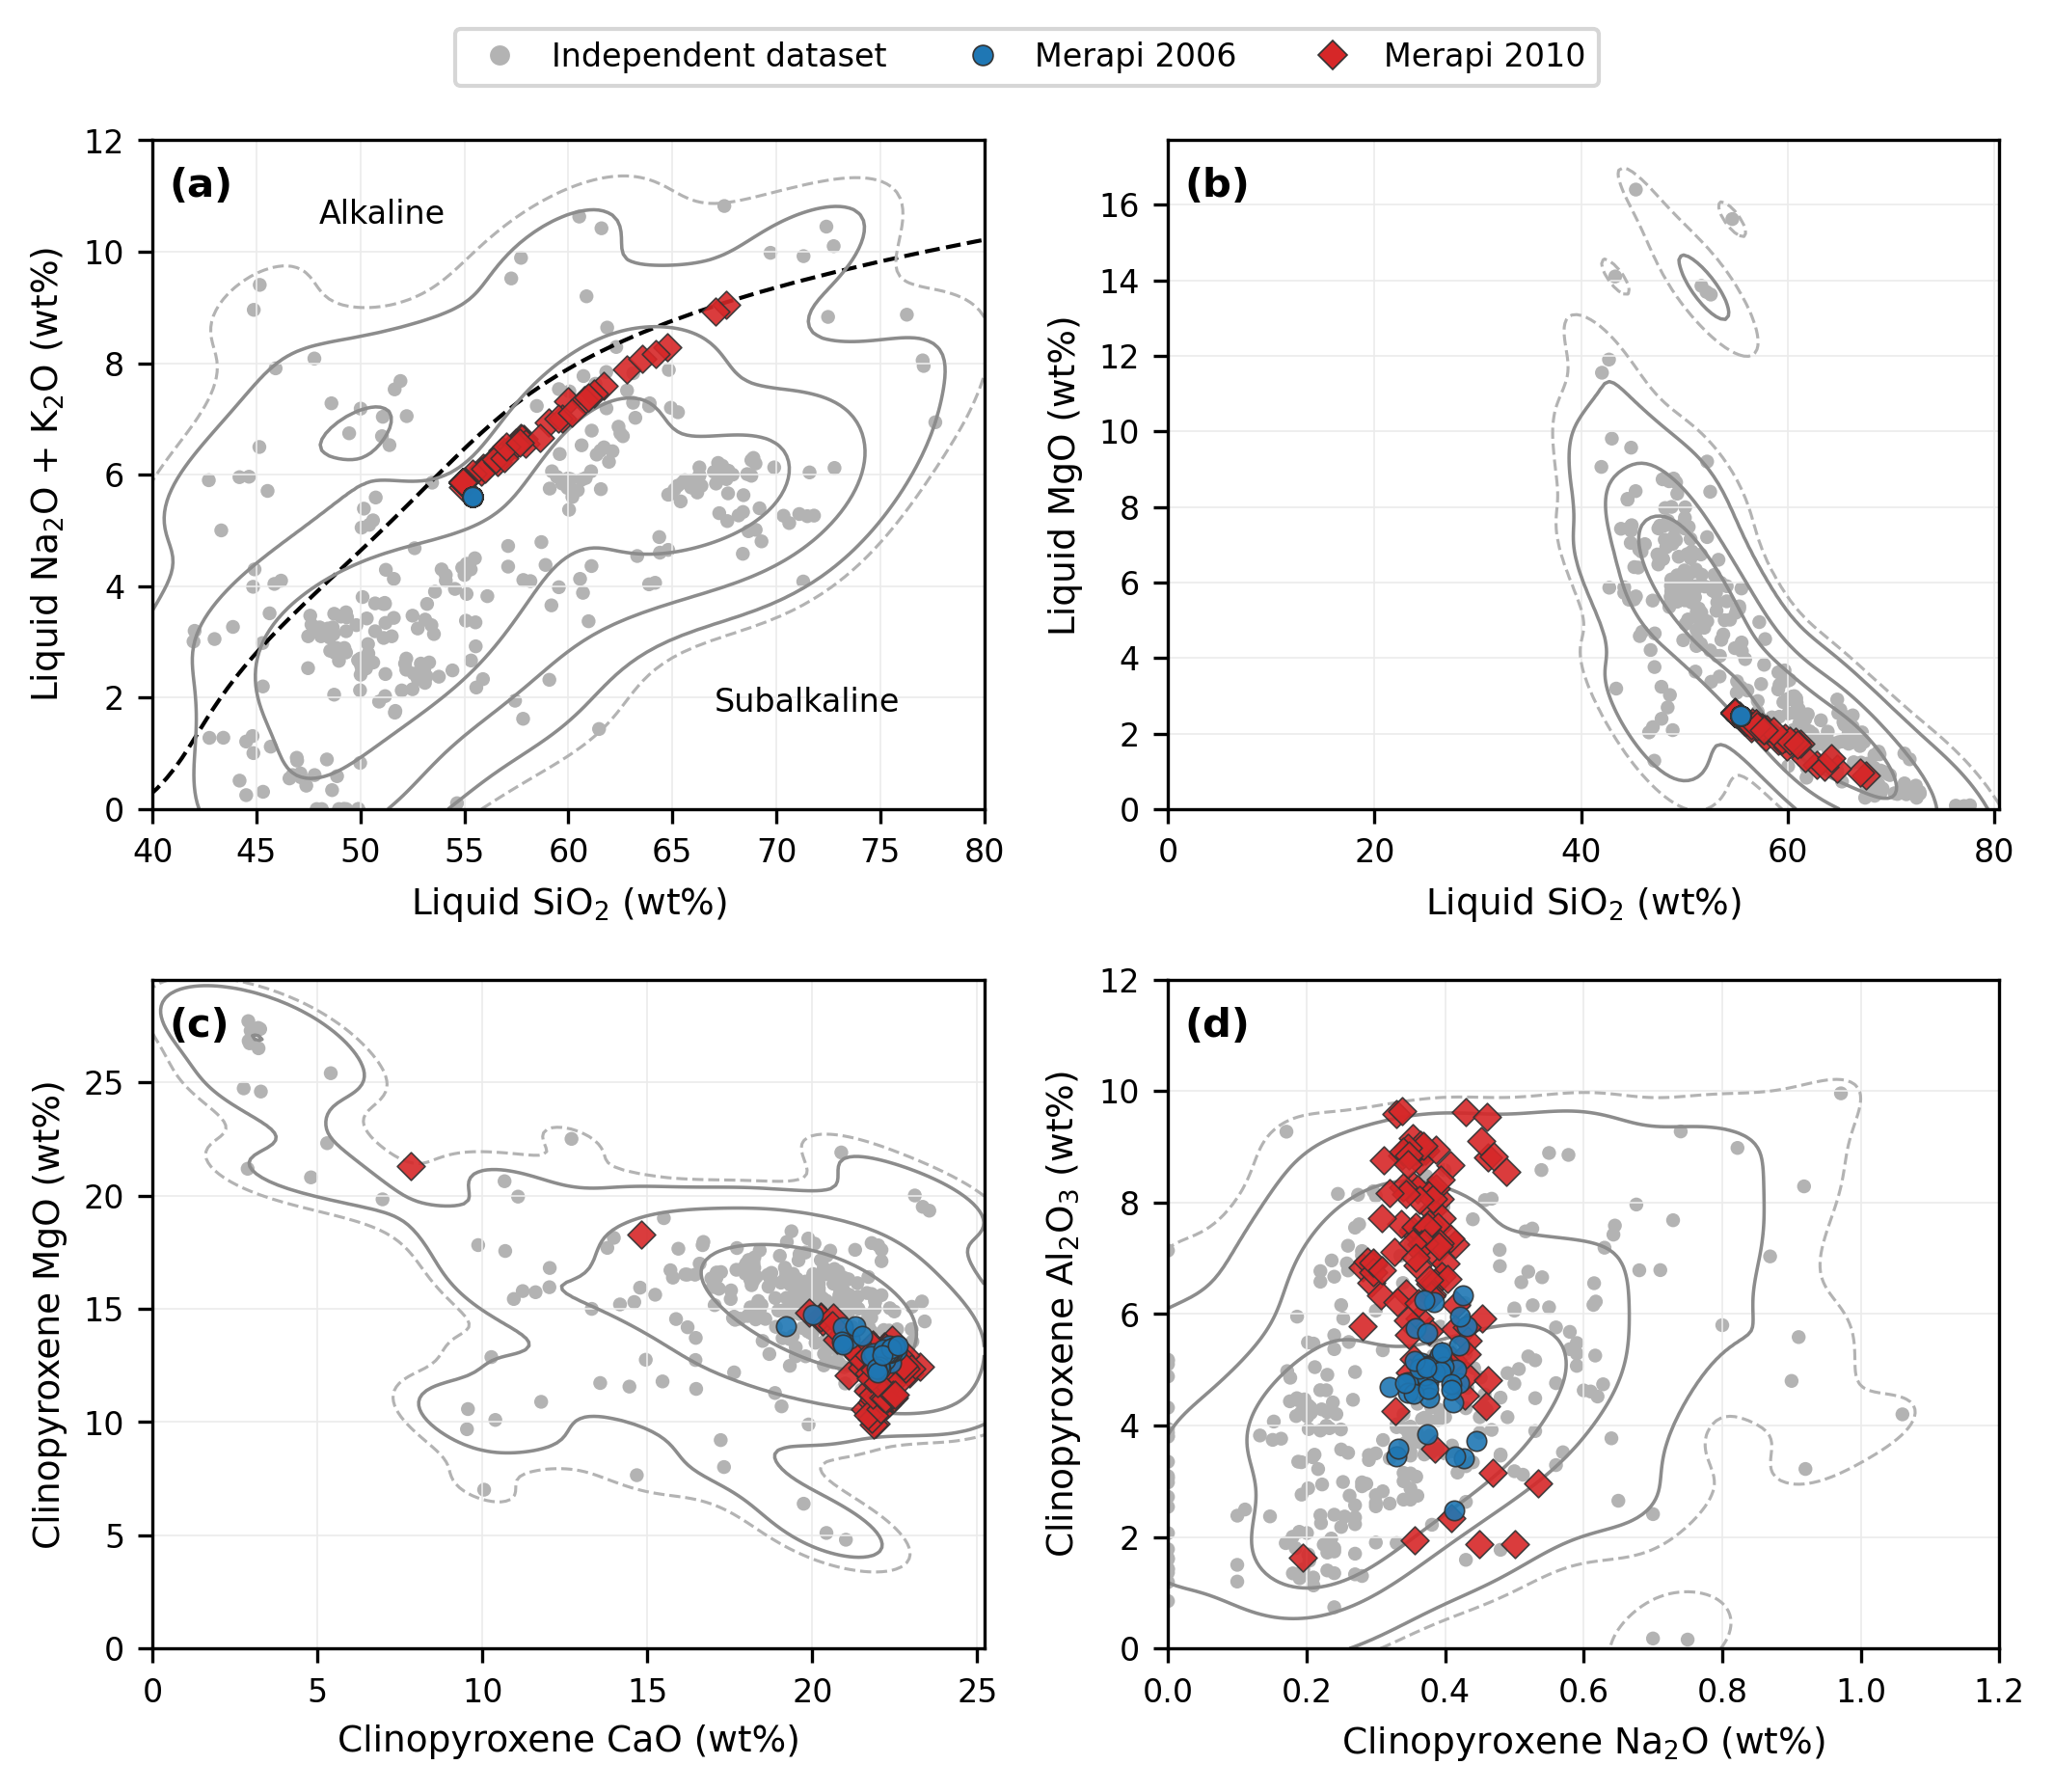

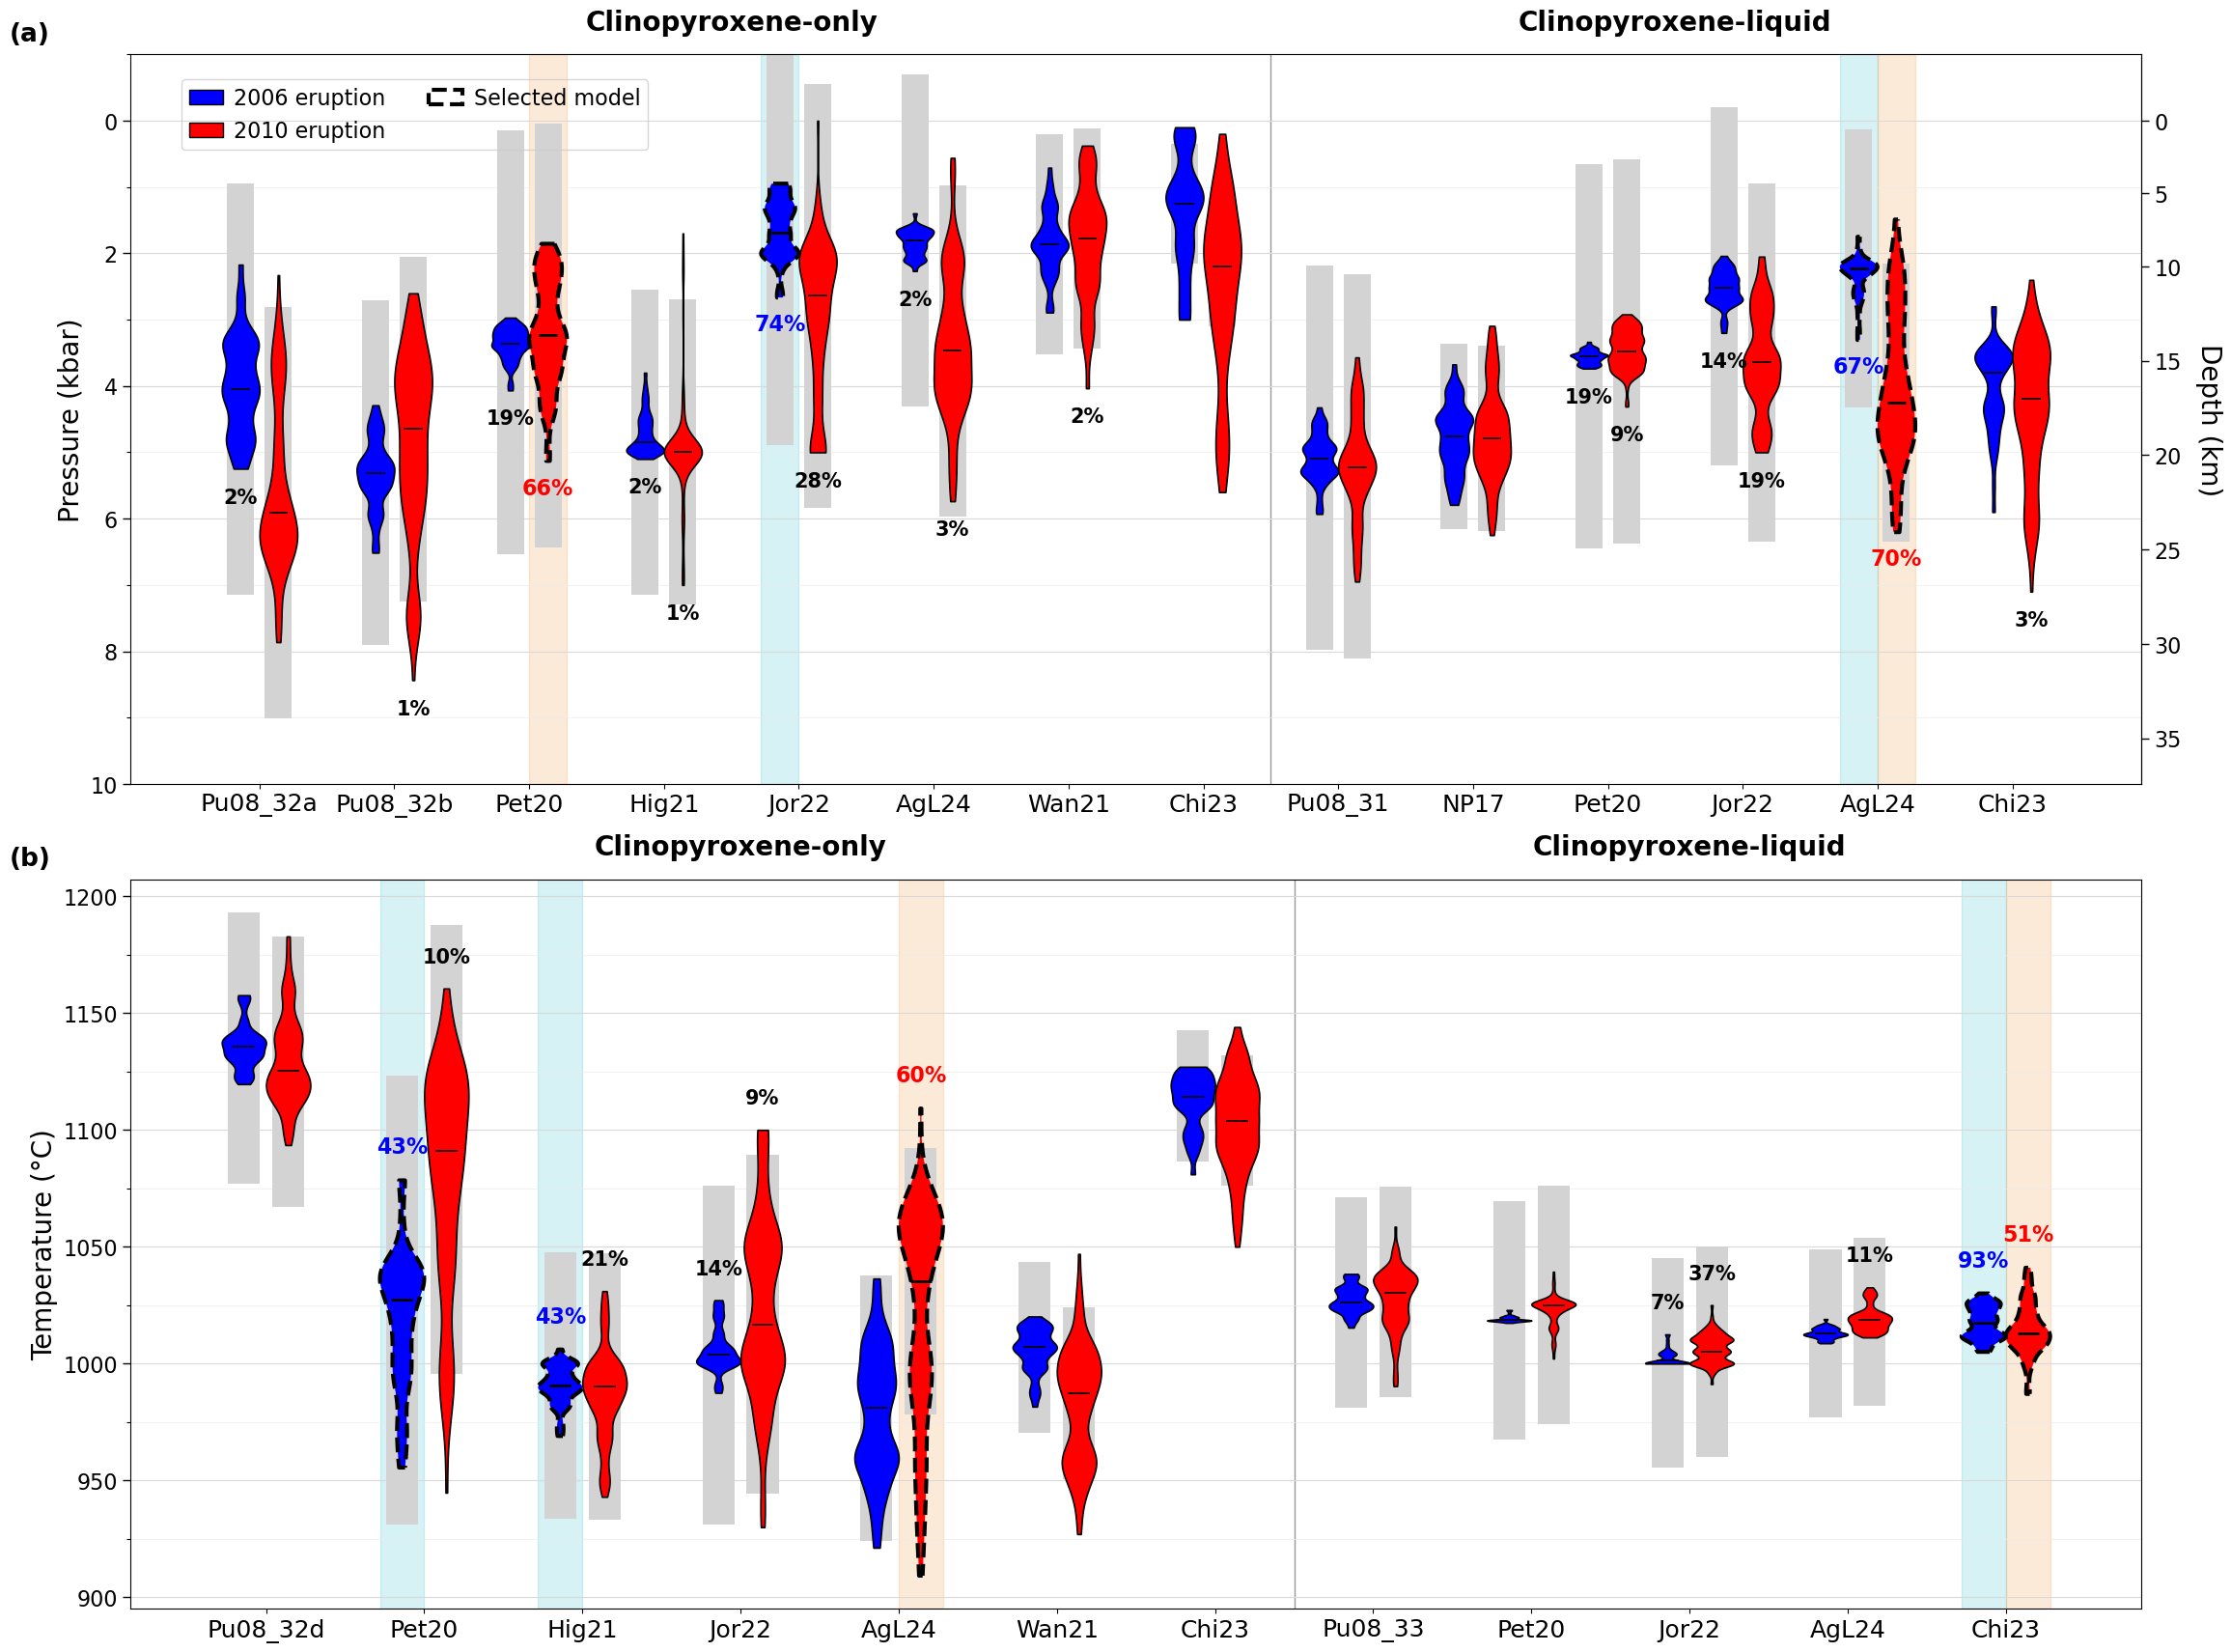

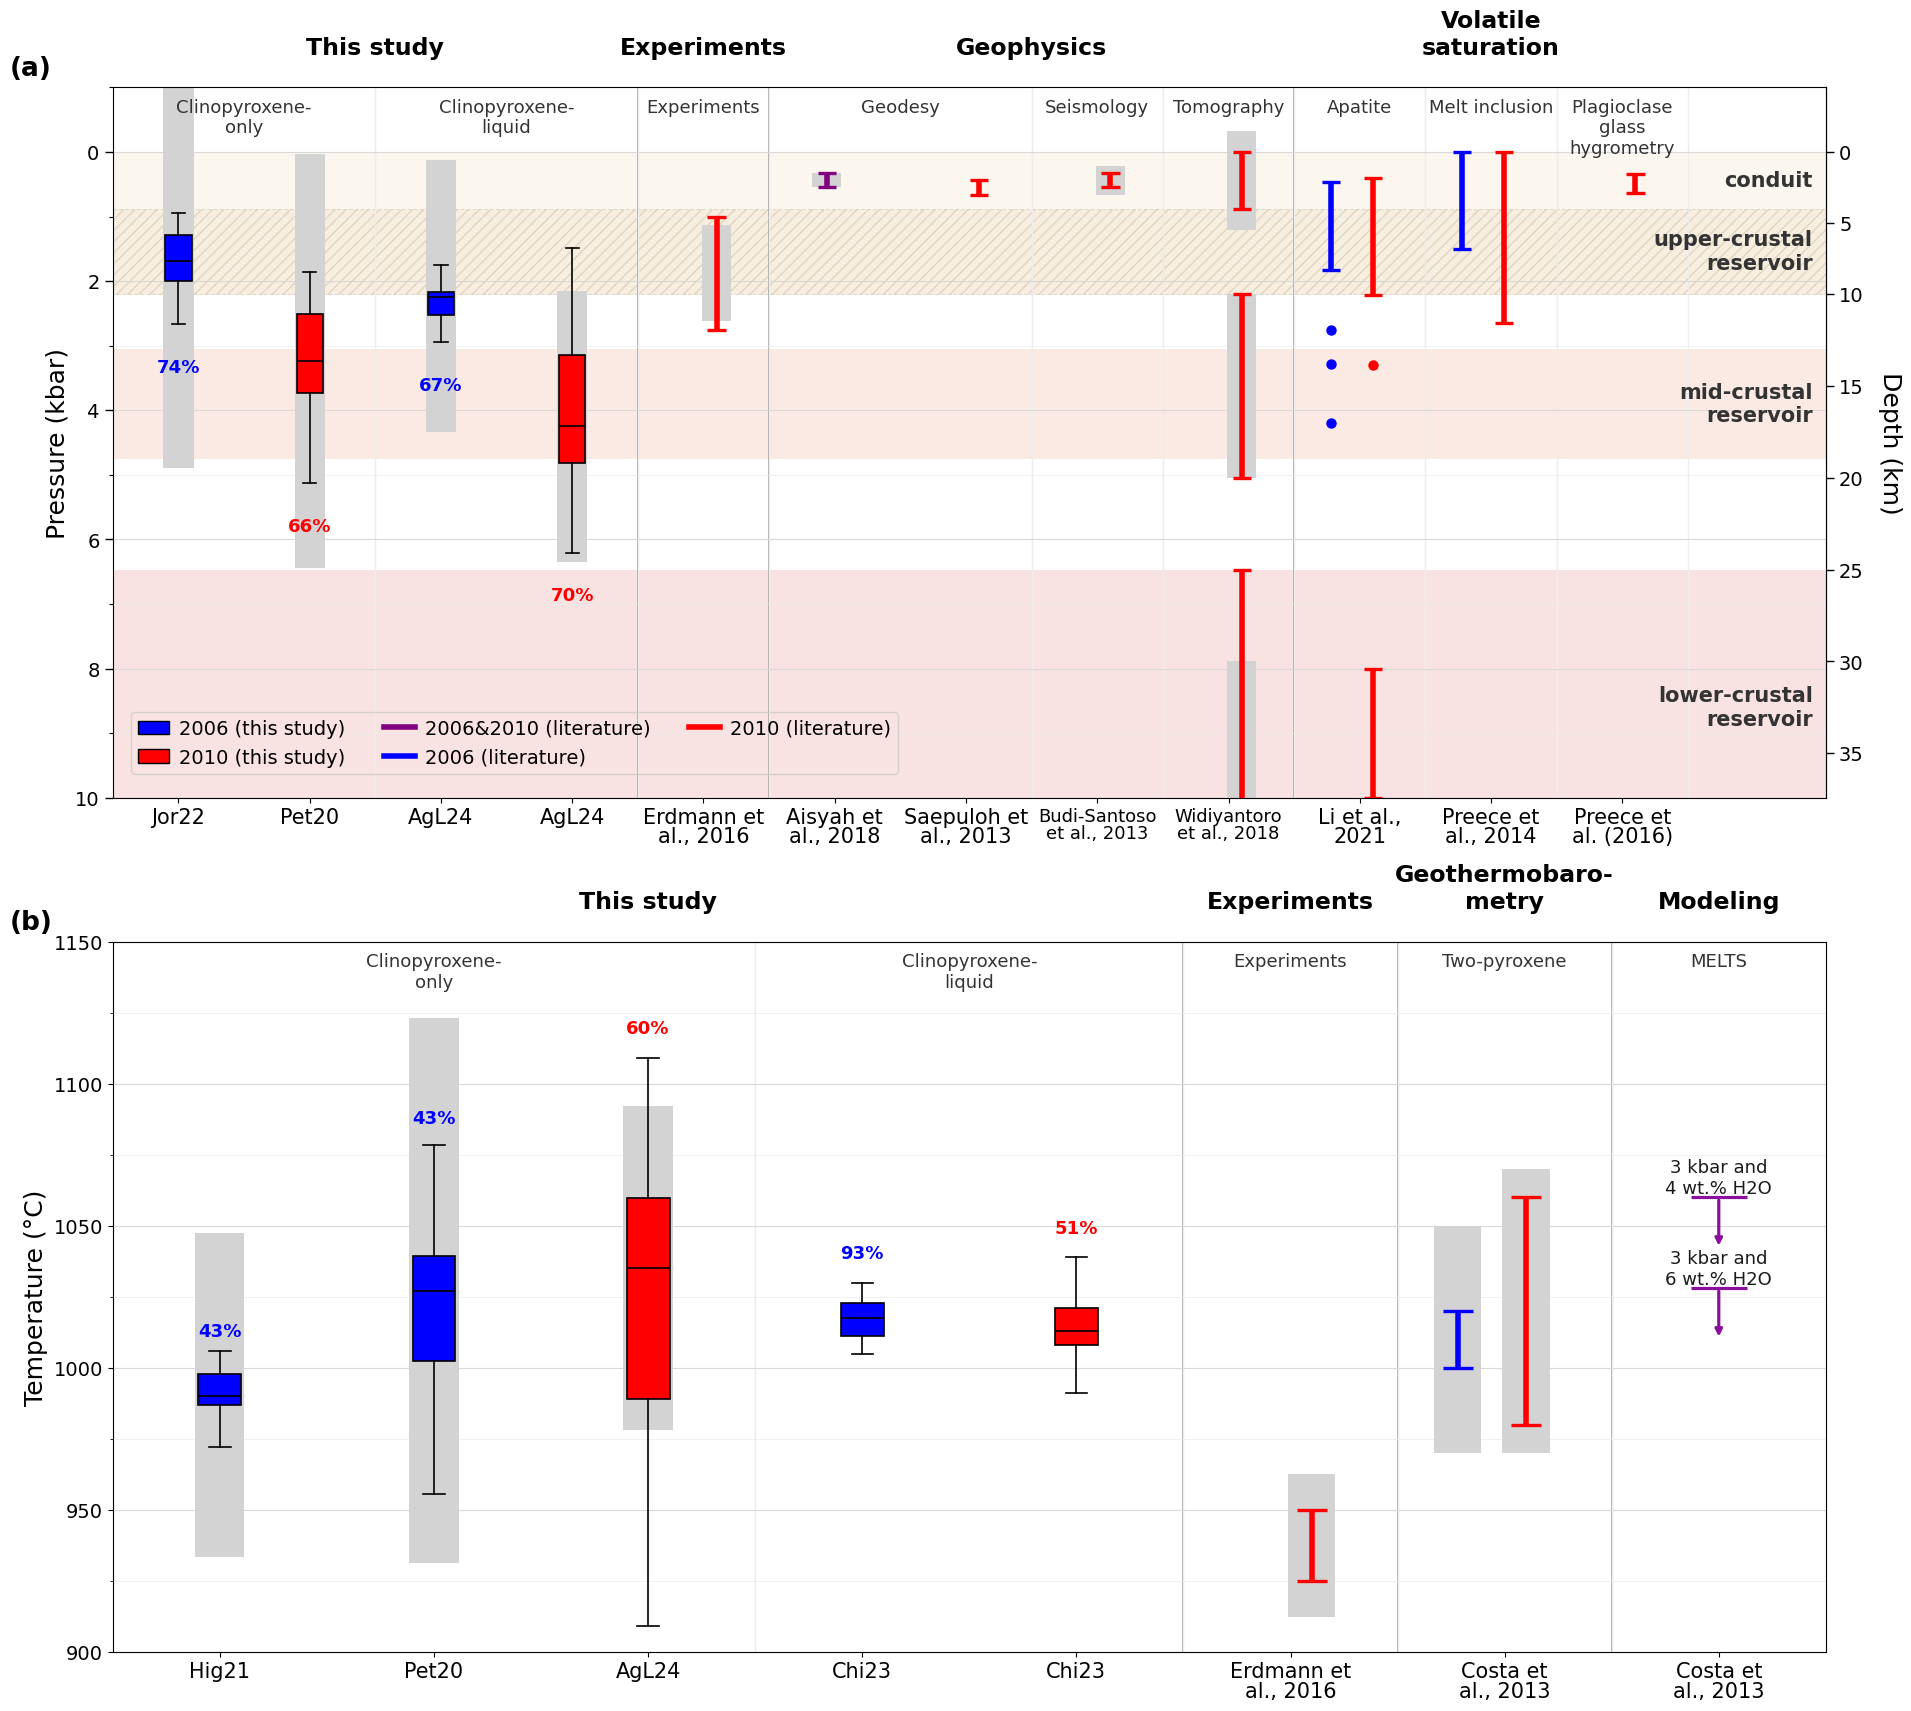

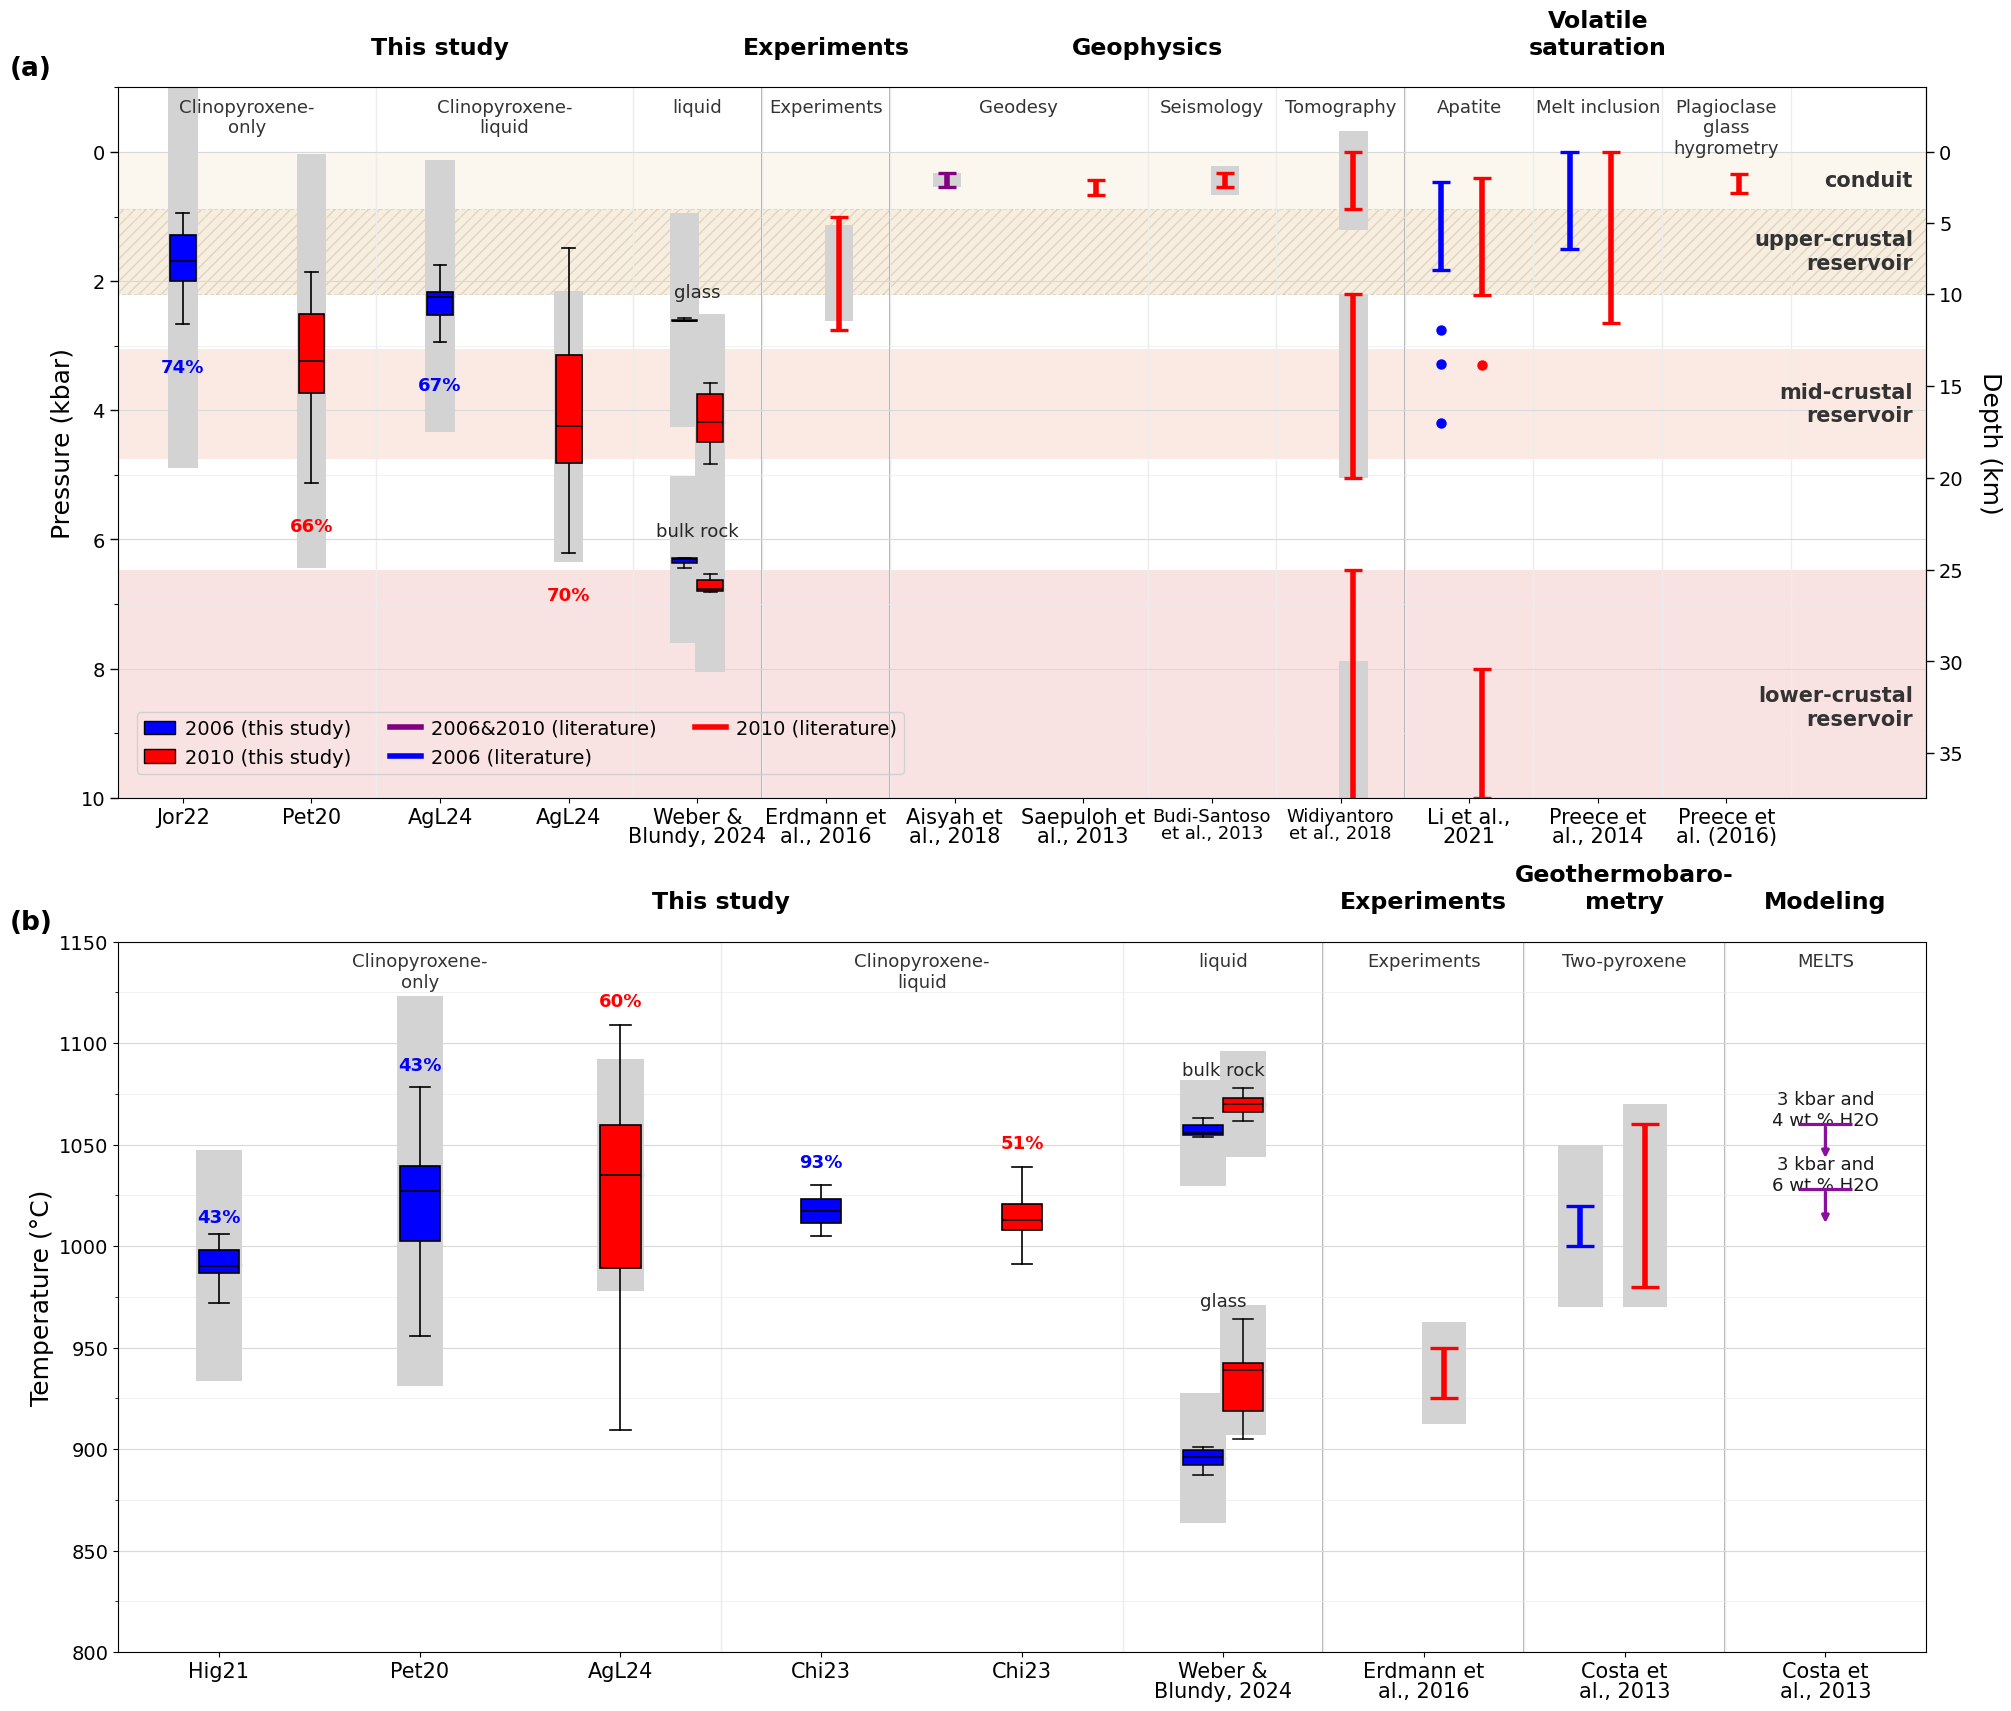

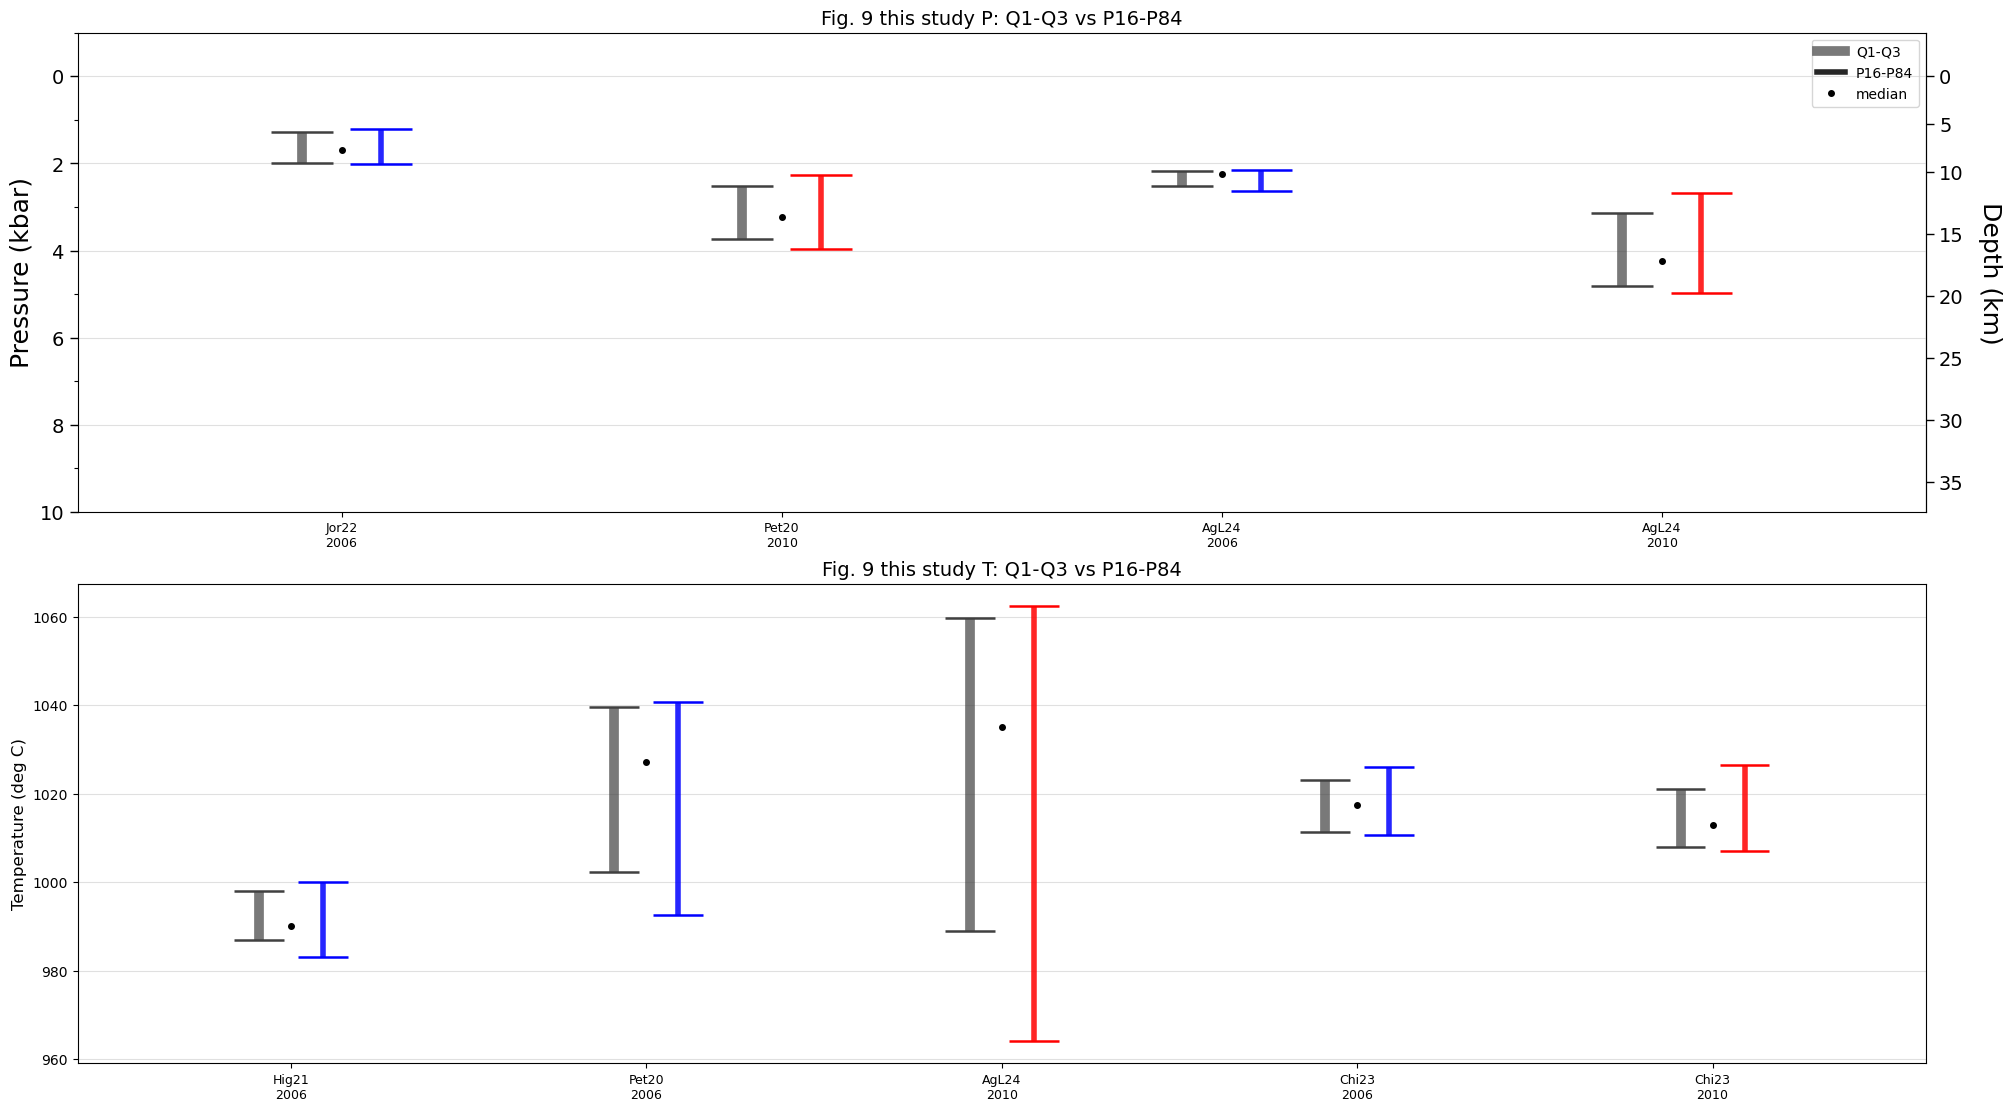

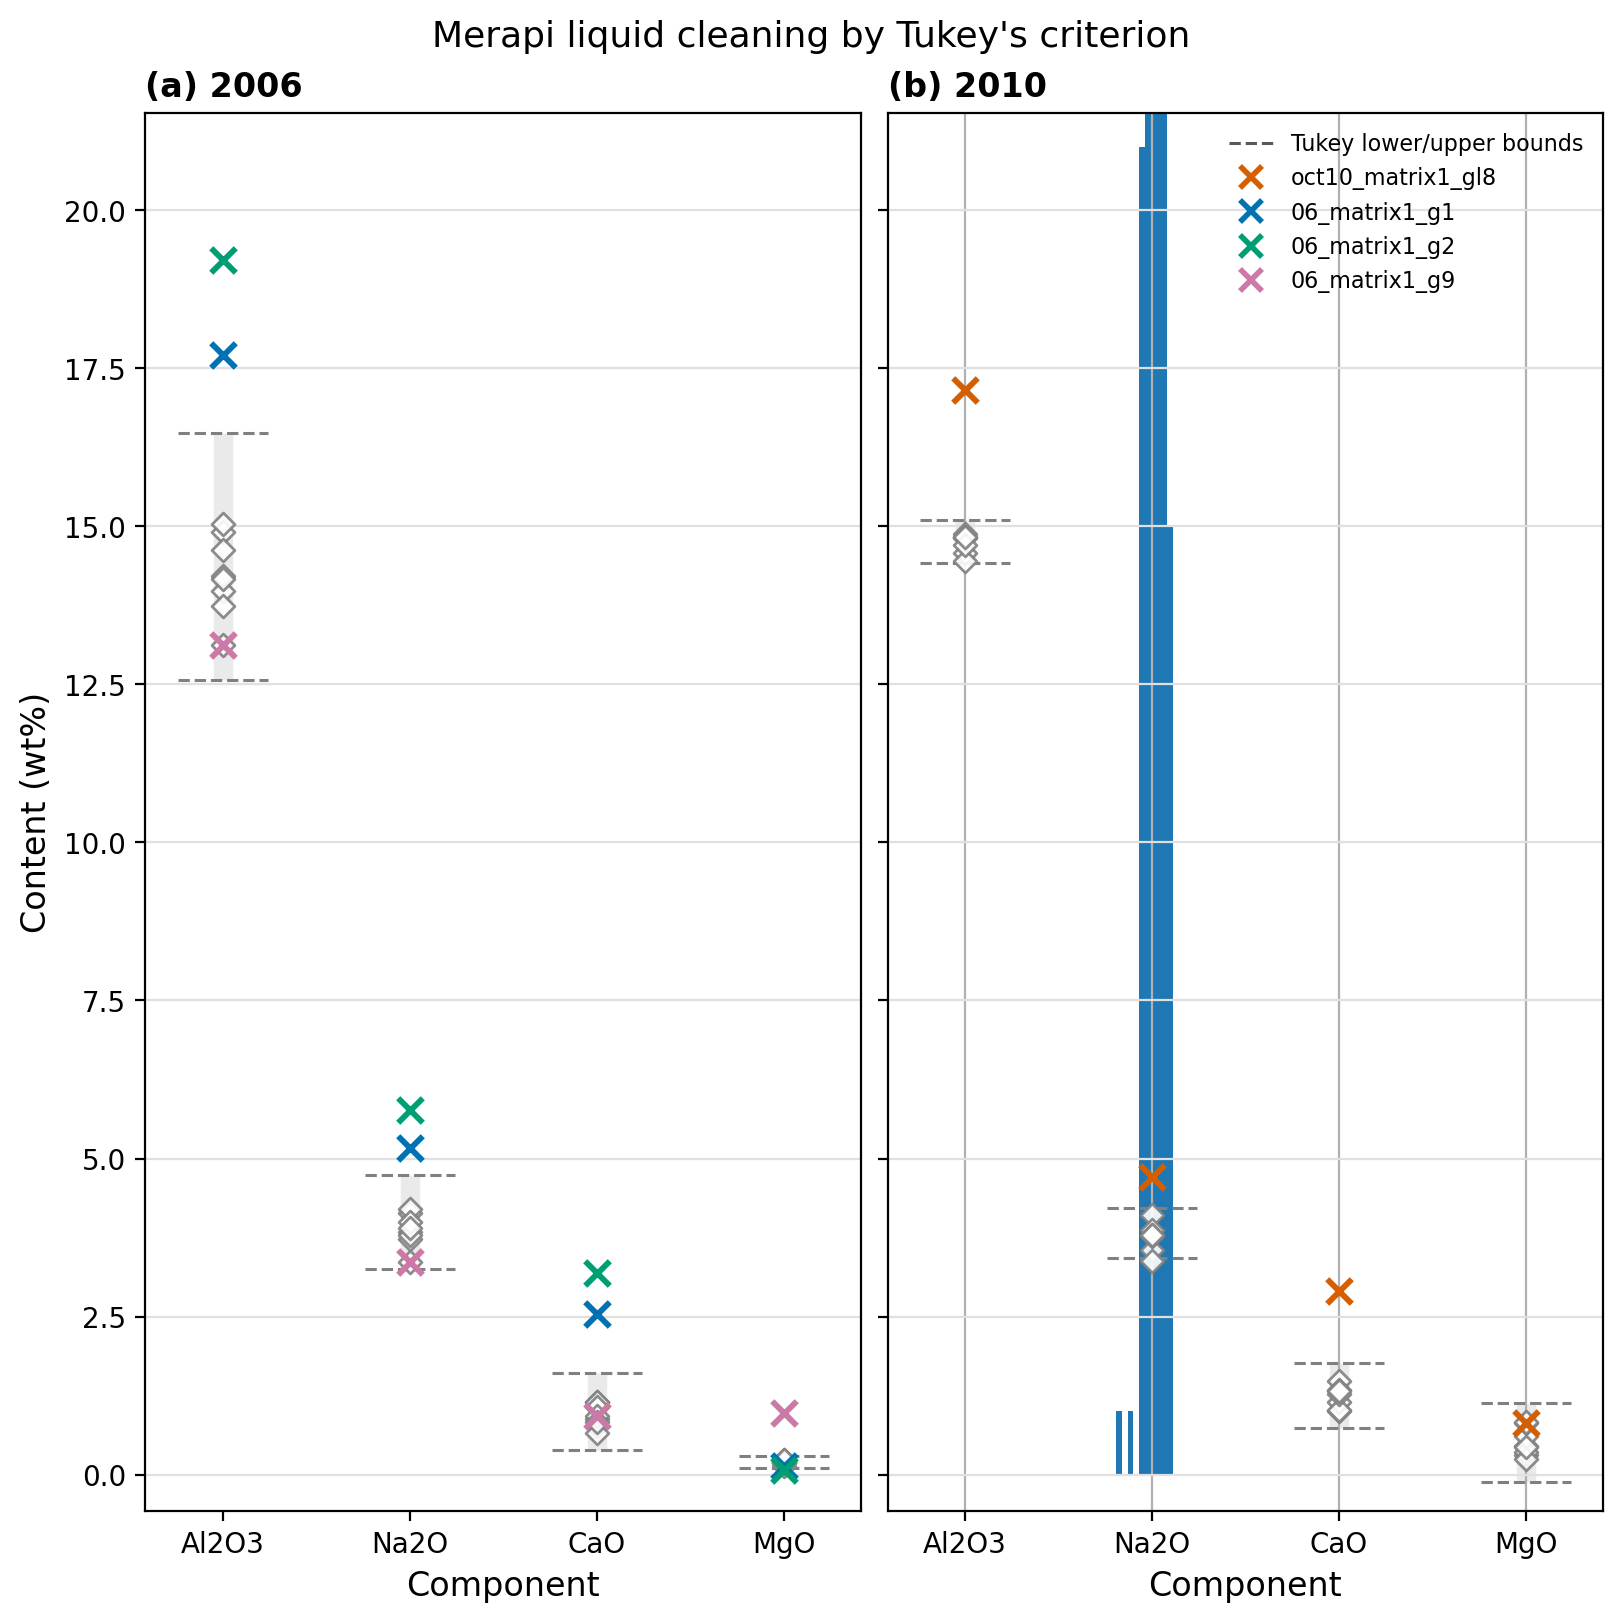

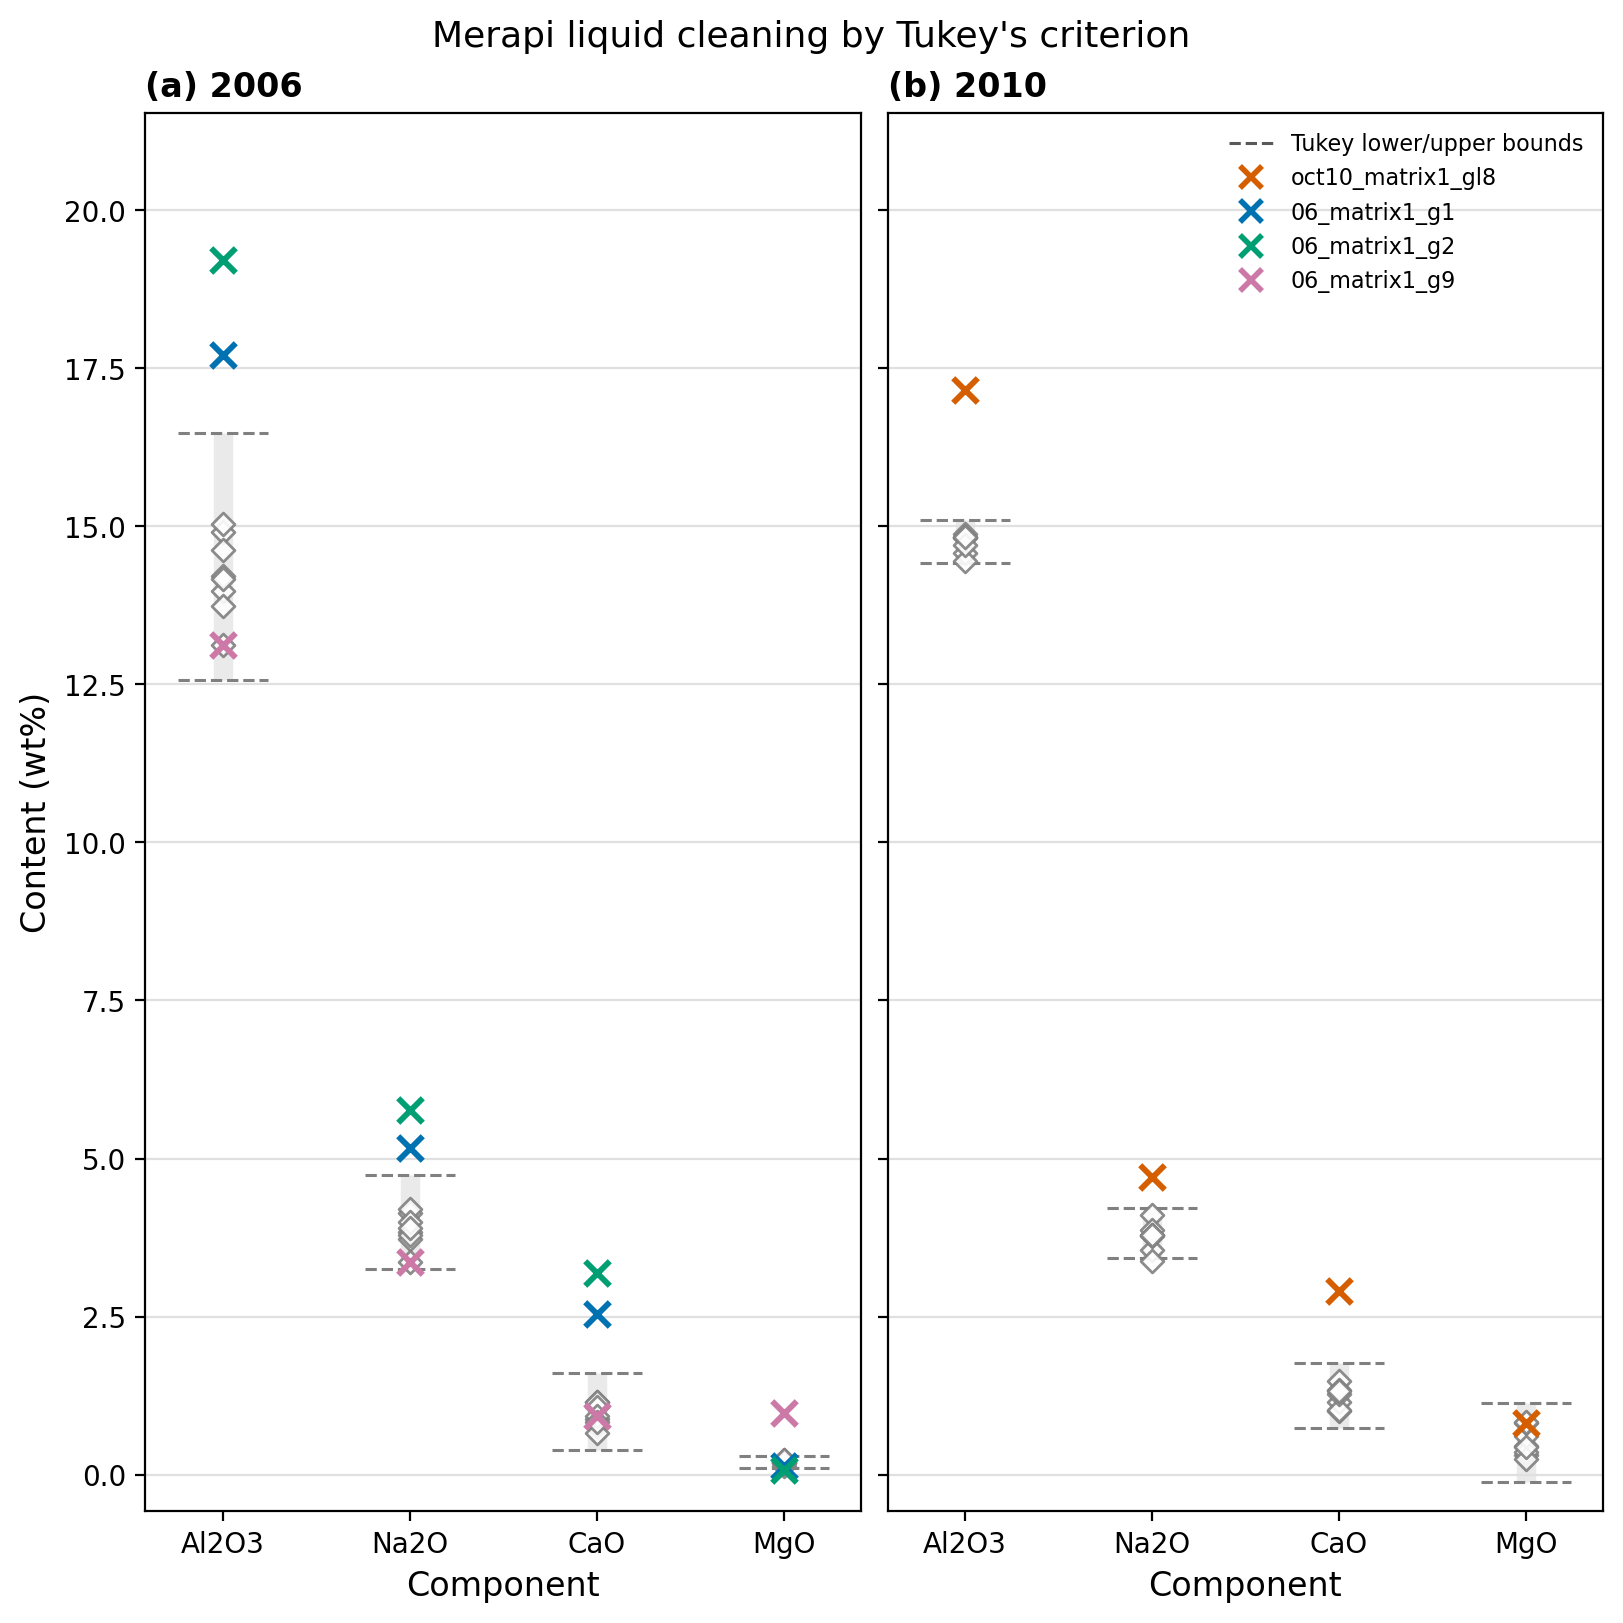

In [48]:
from paper.scripts.figure_helpers import save_figure_pdf_png

liq_before_clean = pd.read_excel(os.path.join(DATA_DIR, "merapi_liq_raw.xlsx"))
liq_before_clean.columns = liq_before_clean.columns.str.strip()
liq_before_clean = liq_before_clean[liq_before_clean["glass/bulk"] == "glass"].reset_index(drop=True)
# Define the liquid components used for Tukey screening.
tukey_components = ["Al2O3", "Na2O", "CaO", "MgO"]
tukey_eruptions = [2006, 2010]
sample_id_col = "Sample_id"
tukey_retained_sample_ids = {}
tukey_unmarked_sample_ids = {"oct10_matrix1_g5"}
missing_cols = [col for col in [sample_id_col, "Eruption", *tukey_components] if col not in liq_before_clean.columns]
if missing_cols:
    raise KeyError(f"Missing required liquid columns: {missing_cols}")

eruption_values = pd.to_numeric(liq_before_clean["Eruption"], errors="coerce")
liq_tukey_flags = pd.DataFrame(False, index=liq_before_clean.index, columns=tukey_components)
liq_tukey_bounds_records = []

for eruption in tukey_eruptions:
    eruption_mask = eruption_values.eq(eruption)
    for component in tukey_components:
        values = pd.to_numeric(liq_before_clean.loc[eruption_mask, component], errors="coerce")
        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        component_values = pd.to_numeric(liq_before_clean[component], errors="coerce")
        component_outlier = eruption_mask & ((component_values < lower_bound) | (component_values > upper_bound))
        liq_tukey_flags.loc[component_outlier, component] = True

        liq_tukey_bounds_records.append(
            {
                "Eruption": eruption,
                "Component": component,
                "Q1": q1,
                "Q3": q3,
                "IQR": iqr,
                "Lower_bound": lower_bound,
                "Upper_bound": upper_bound,
                "n": values.notna().sum(),
                "n_rejected": int(component_outlier.sum()),
            }
        )

liq_sample_ids = liq_before_clean[sample_id_col].astype(str).str.strip()
liq_tukey_plot_flags = liq_tukey_flags.copy()
liq_tukey_plot_flags = liq_tukey_plot_flags.mask(liq_sample_ids.isin(tukey_unmarked_sample_ids), False)
liq_tukey_retained_mask = liq_sample_ids.isin(tukey_retained_sample_ids) & liq_tukey_flags.any(axis=1)
liq_tukey_flags = liq_tukey_flags.mask(liq_tukey_retained_mask, False)

liq_before_clean = liq_before_clean.copy()
liq_before_clean["Tukey_flagged"] = liq_tukey_plot_flags.any(axis=1)
liq_before_clean["Tukey_flagged_components"] = liq_tukey_plot_flags.apply(
    lambda row: ", ".join(row.index[row]), axis=1
)
liq_before_clean["Tukey_retained_override"] = liq_tukey_retained_mask
liq_before_clean["Tukey_outlier"] = liq_tukey_flags.any(axis=1)
liq_before_clean["Tukey_outlier_components"] = liq_tukey_flags.apply(
    lambda row: ", ".join(row.index[row]), axis=1
)
liq_tukey_bounds = pd.DataFrame(liq_tukey_bounds_records)
liq_tukey_flagged = liq_before_clean.loc[liq_before_clean["Tukey_flagged"]].copy()
liq_tukey_rejected = liq_before_clean.loc[liq_before_clean["Tukey_outlier"]].copy()
liq_clean = liq_before_clean.loc[~liq_before_clean["Tukey_outlier"]].reset_index(drop=True)


print(f"Before liquid cleaning: {len(liq_before_clean)}")
print(f"After Tukey liquid cleaning: {len(liq_clean)}")
print(f"Tukey-flagged liquid analyses: {len(liq_tukey_flagged)}")
print(f"Rejected liquid analyses: {len(liq_tukey_rejected)}")
print(f"Retained borderline Tukey-flagged analyses: {int(liq_tukey_retained_mask.sum())}")
display(liq_tukey_bounds.round(3))

rejected_display_cols = [
    col for col in ["Sample_id", "Eruption", "Source", "glass/bulk", "Tukey_flagged_components", "Tukey_retained_override", *tukey_components]
    if col in liq_tukey_flagged.columns
]
if len(liq_tukey_flagged) > 0:
    display(liq_tukey_flagged[rejected_display_cols].sort_values(["Eruption", "Tukey_flagged_components"]))

from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(8, 8), dpi = 200, sharey=True, constrained_layout=True)
panel_labels = {2006: "(a) 2006", 2010: "(b) 2010"}
component_colors = {
    "Al2O3": "grey",
    "Na2O": "grey",
    "CaO":"grey",
    "MgO": "grey",
}
flagged_sample_ids = liq_before_clean.loc[liq_tukey_plot_flags.any(axis=1), sample_id_col].astype(str).str.strip().drop_duplicates().tolist()
flagged_sample_palette = ["#D55E00", "#0072B2", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#332288", "#AA4499"]
flagged_sample_colors = {
    sample_id: flagged_sample_palette[i % len(flagged_sample_palette)]
    for i, sample_id in enumerate(flagged_sample_ids)
}

plot_values = pd.to_numeric(liq_before_clean[tukey_components].stack(), errors="coerce")
bound_values = liq_tukey_bounds[["Lower_bound", "Upper_bound"]].stack()
y_min = min(plot_values.min(), bound_values.min())
y_max = max(plot_values.max(), bound_values.max())
y_pad = (y_max - y_min) * 0.12 if y_max > y_min else 1.0

for ax, eruption in zip(axes, tukey_eruptions):
    plot_data = liq_before_clean.loc[eruption_values.eq(eruption)].copy()
    for x_pos, component in enumerate(tukey_components):
        y = pd.to_numeric(plot_data[component], errors="coerce")
        component_flags = liq_tukey_plot_flags.loc[plot_data.index, component]
        sample_ids = plot_data[sample_id_col].astype(str).str.strip()
        inlier_mask = y.notna() & ~component_flags
        outlier_mask = y.notna() & component_flags
        color = component_colors[component]

        bounds_row = liq_tukey_bounds.loc[
            (liq_tukey_bounds["Eruption"].eq(eruption))
            & (liq_tukey_bounds["Component"].eq(component))
        ].iloc[0]
        lower_bound = bounds_row["Lower_bound"]
        upper_bound = bounds_row["Upper_bound"]

        ax.vlines(x_pos, lower_bound, upper_bound, color=color, linewidth=7, alpha=0.16, zorder=1)
        ax.hlines([lower_bound, upper_bound], x_pos - 0.24, x_pos + 0.24,
                  color=color, linestyle="--", linewidth=1.1, zorder=2)
        ax.scatter(np.full(inlier_mask.sum(), x_pos), y.loc[inlier_mask],
                   s=34, facecolor="white", edgecolor=color, linewidth=1.0, alpha=0.9, zorder=3)
        for sample_id in flagged_sample_ids:
            sample_outlier_mask = sample_ids.eq(sample_id)
            if sample_outlier_mask.any():
                ax.scatter(np.full(sample_outlier_mask.sum(), x_pos), y.loc[sample_outlier_mask],
                           s=78, marker="x", color=flagged_sample_colors[sample_id], linewidth=2.1, zorder=4)
        # ax.text(x_pos, upper_bound + y_pad * 0.12,
        #         f"{lower_bound:.2f}\n{upper_bound:.2f}",
        #         ha="center", va="bottom", fontsize=8, color=color)

    ax.set_title(panel_labels[eruption], loc="left", fontsize=12, fontweight="bold")
    ax.set_xticks(range(len(tukey_components)))
    ax.set_xticklabels(tukey_components)
    ax.set_xlabel("Component")
    ax.grid(axis="y", color="0.88", linewidth=0.8)
    ax.set_ylim(y_min - y_pad * 0.2, y_max + y_pad)

axes[0].set_ylabel("Content (wt%)")
legend_handles = [
    Line2D([0], [0], color="0.35", linestyle="--", linewidth=1.1,
           label="Tukey lower/upper bounds"),
]
flagged_legend_handles = [
    Line2D([0], [0], marker="x", color=flagged_sample_colors[sample_id], linestyle="None",
           markersize=8, markeredgewidth=2,
           label=f"{sample_id}{' (retained)' if sample_id in tukey_retained_sample_ids else ''}")
    for sample_id in flagged_sample_ids
]
axes[1].legend(handles=legend_handles + flagged_legend_handles, frameon=False, loc="upper right", fontsize=8)
fig.suptitle("Merapi liquid cleaning by Tukey's criterion", fontsize=13)
save_figure_pdf_png(fig, IMAGES_DIR, "Fig_s13_Merapi_liquid_cleaning", dpi=300, bbox_inches="tight")
plt.show()


## 3. Cpx-Liquid Pairing

### Pairing Setup

In [49]:
liq_cols = ['SiO2', 'TiO2',
       'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']


In [50]:
liq_2006 = liq_raw[liq_raw["Eruption"]==2006].reset_index(drop=True)
liq_2010 = liq_raw[liq_raw["Eruption"]==2010].reset_index(drop=True)

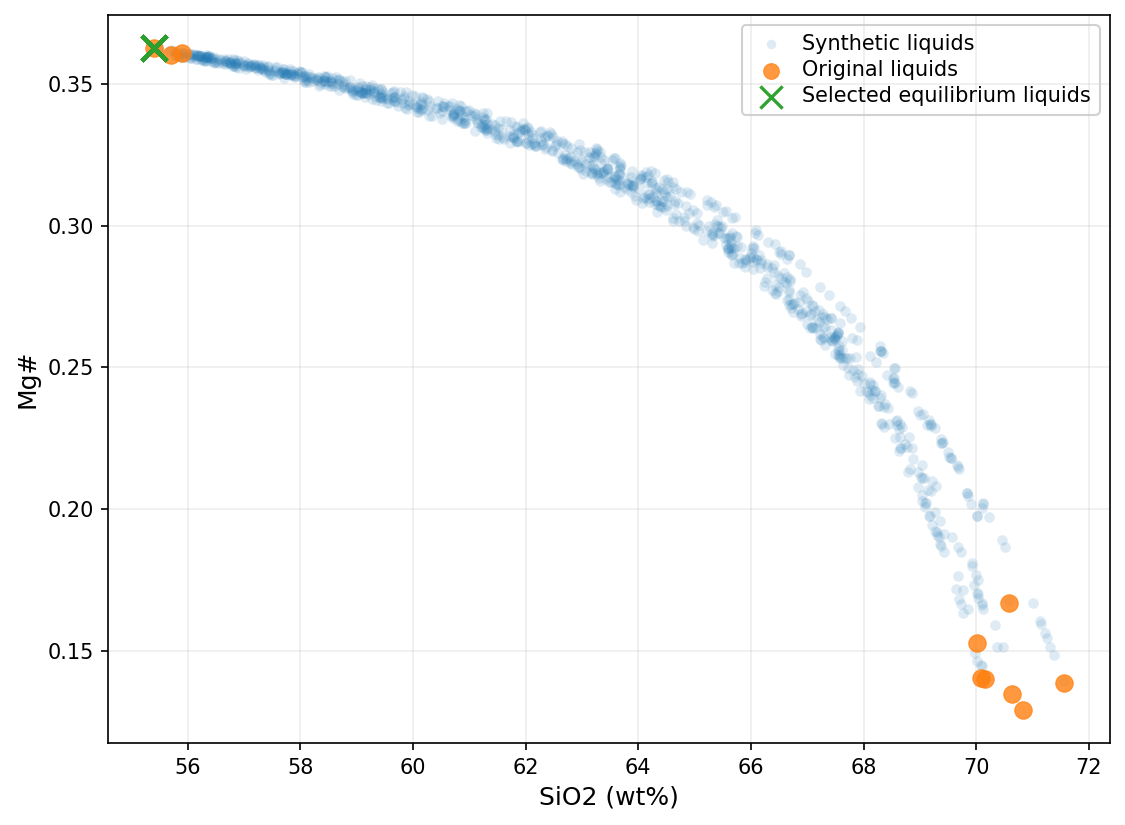

42

In [51]:
from aims4pt.data_tools.eq_pairing import pair_mineral_liquid_by_kd


# res_06 = pair_mineral_liquid_by_kd(
#     cpx_06_input, liq_2006[liq_cols],
#     kd=0.28, error=0.08,
#     interpolate_liq=True,
#     interp_mode="between",
#     n_synth=1000,
#     random_state=42
# )
res_06 = pair_mineral_liquid_by_kd(
    X_mine=cpx_06_input,
    X_liq=liq_2006[liq_cols],     # Defines the expected column set/order.
    one_to_one=True,
    interpolate_liq=True,
    interp_mode="endmembers",
    n_synth=1000,
    endmember1=liq_2006[liq_2006['glass/bulk']=="bulk"][liq_cols], # bulk
    endmember2=liq_2006[liq_2006['glass/bulk']=="glass"][liq_cols], # glass
    random_state=42,

)

paired_cpx_06, paired_liq_06 = res_06.cleaned_minerals, res_06.cleaned_liquids
paired_cpx_06_pass = paired_cpx_06[res_06.pairs_pass_mask].reset_index(drop=True)
paired_liq_06_pass = paired_liq_06[res_06.pairs_pass_mask].reset_index(drop=True)


len(paired_cpx_06_pass)

In [52]:
# kd range 
res_06.pairs["kd_value"].describe()

count    170.000000
mean       0.191082
std        0.018082
min        0.155929
25%        0.179269
50%        0.187270
75%        0.198592
max        0.256263
Name: kd_value, dtype: float64

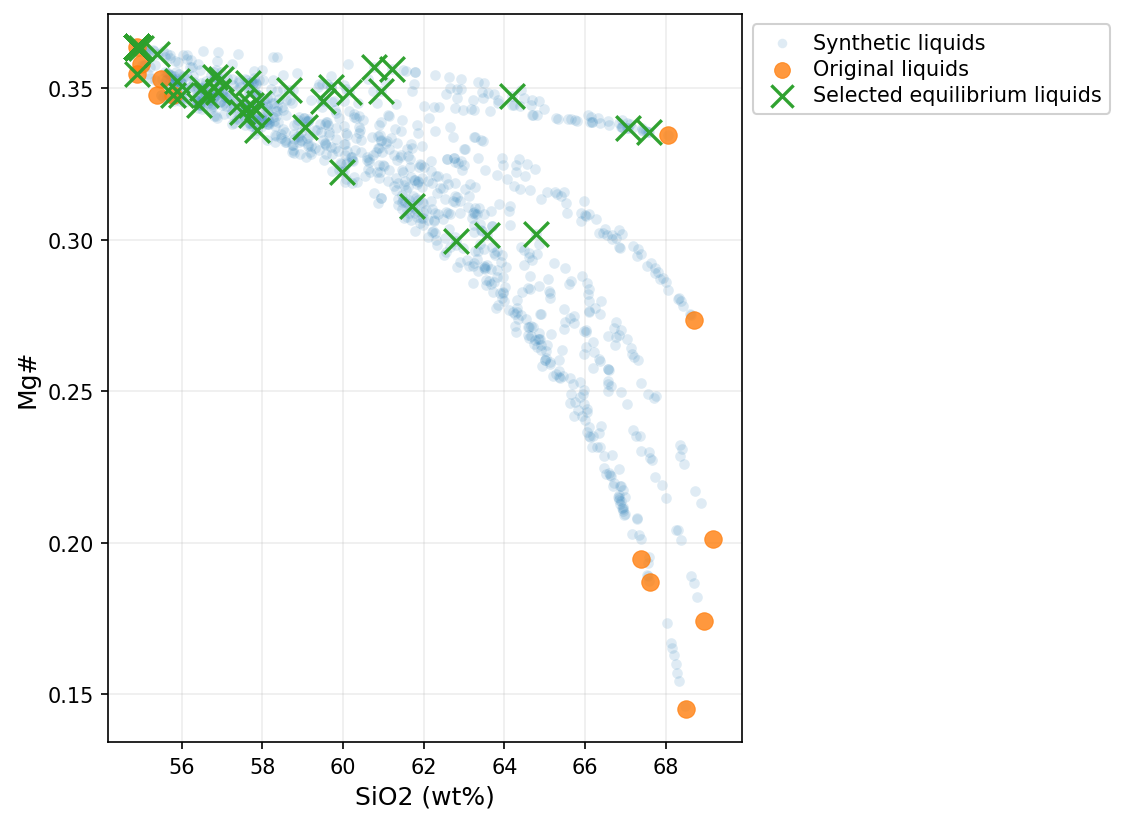

105

In [53]:
from aims4pt.data_tools.eq_pairing import pair_mineral_liquid_by_kd


# res_10 = pair_mineral_liquid_by_kd(
#     cpx_10_input, liq_2010[liq_cols],
#     kd=0.28, error=0.08,
#     interpolate_liq=True,
#     interp_mode="between",
#     n_synth=2000,
#     random_state=42
# )

res_10 = pair_mineral_liquid_by_kd(
    X_mine=cpx_10_input,
    X_liq=liq_2010[liq_cols],     # Defines the expected column set/order.
    one_to_one=True,
    interpolate_liq=True,
    interp_mode="endmembers",
    n_synth=1000,
    endmember1=liq_2010[liq_2010['glass/bulk']=="bulk"][liq_cols], # bulk
    endmember2=liq_2010[liq_2010['glass/bulk']=="glass"][liq_cols], # glass
    random_state=42,

)
paired_cpx_10, paired_liq_10 = res_10.cleaned_minerals, res_10.cleaned_liquids
paired_cpx_10_pass = paired_cpx_10[res_10.pairs_pass_mask].reset_index(drop=True)
paired_liq_10_pass = paired_liq_10[res_10.pairs_pass_mask].reset_index(drop=True)



len(paired_cpx_10_pass)


In [54]:
res_06.pairs[res_06.pairs_pass_mask]["kd_value"]

0      0.200353
1      0.209108
2      0.221436
3      0.249757
4      0.232326
10     0.206466
11     0.200789
35     0.216668
36     0.222003
37     0.212630
38     0.214592
39     0.219074
40     0.213424
41     0.212598
42     0.231847
43     0.227528
44     0.207882
58     0.246977
59     0.207509
74     0.203141
76     0.201843
77     0.206352
80     0.207735
81     0.210093
82     0.209059
83     0.207758
85     0.200315
86     0.206326
87     0.208202
88     0.200551
89     0.208569
90     0.214185
91     0.208256
108    0.218088
109    0.244404
110    0.250433
111    0.256263
112    0.223421
116    0.202240
135    0.207229
139    0.224372
140    0.218847
Name: kd_value, dtype: float64

## 4. Cpx-Liquid Thermobarometry

### Cpx-Liquid Setup

In [55]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
P_cpx_liq_pool = [model for model in P_model_pool if not model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_liq_P_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_liq_P_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_liq_P_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_liq_P_06 = workflow_thermobarometry(P_cpx_liq_pool)
    workflow_cpx_liq_P_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_liq_P_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_liq_P_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_liq_P_10 = workflow_thermobarometry(P_cpx_liq_pool)
    workflow_cpx_liq_P_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_liq_P_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_liq_P_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_liq_P_{timestamp}_report.xlsx"

from aims4pt.reporting.excel import report_excel
report_excel(
    workflow_obj=workflow_cpx_liq_P_06,
    model_list =P_cpx_liq_pool,
    original_data=paired_cpx_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_liq_P_10,
    model_list =P_cpx_liq_pool,
    original_data=paired_cpx_10_pass,
    out_path=report_path_2010
)

Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2006_P_workflow_cpx_liq_P_20260530_1500.pkl
Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2010_P_workflow_cpx_liq_P_20260530_1500.pkl


In [56]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
T_cpx_liq_pool = [model for model in T_model_pool if not model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_liq_T_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_liq_T_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_liq_T_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_liq_T_06 = workflow_thermobarometry(T_cpx_liq_pool)
    workflow_cpx_liq_T_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_liq_T_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_liq_T_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_liq_T_10 = workflow_thermobarometry(T_cpx_liq_pool)
    workflow_cpx_liq_T_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_liq_T_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_liq_T_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_liq_T_{timestamp}_report.xlsx"

report_excel(
    workflow_obj=workflow_cpx_liq_T_06,
    model_list =T_cpx_liq_pool,
    original_data=paired_cpx_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_liq_T_10,
    model_list =T_cpx_liq_pool,
    original_data=paired_cpx_10_pass,
    out_path=report_path_2010
)

Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2006_T_workflow_cpx_liq_T_20260530_1500.pkl
Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2010_T_workflow_cpx_liq_T_20260530_1500.pkl


## 5. Cpx-Only Thermobarometry

### Cpx-Only Setup

In [57]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
P_cpx_only_pool = [model for model in P_model_pool if model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_only_P_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_only_P_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_only_P_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_only_P_06 = workflow_thermobarometry(P_cpx_only_pool)
    workflow_cpx_only_P_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_only_P_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_only_P_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_only_P_10 = workflow_thermobarometry(P_cpx_only_pool)
    workflow_cpx_only_P_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_only_P_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_only_P_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_only_P_{timestamp}_report.xlsx"

report_excel(
    workflow_obj=workflow_cpx_only_P_06,
    model_list =P_cpx_only_pool,
    original_data=paired_liq_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_only_P_10,
    model_list =P_cpx_only_pool,
    original_data=paired_liq_10_pass,
    out_path=report_path_2010
)

Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2006_P_workflow_cpx_only_P_20260530_1500.pkl
Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2010_P_workflow_cpx_only_P_20260530_1500.pkl


In [58]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
T_cpx_only_pool = [model for model in T_model_pool if model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_only_T_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_only_T_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_only_T_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_only_T_06 = workflow_thermobarometry(T_cpx_only_pool)
    workflow_cpx_only_T_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_only_T_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_only_T_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_only_T_10 = workflow_thermobarometry(T_cpx_only_pool)
    workflow_cpx_only_T_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_only_T_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_only_T_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_only_T_{timestamp}_report.xlsx"

report_excel(
    workflow_obj=workflow_cpx_only_T_06,
    model_list =T_cpx_only_pool,
    original_data=paired_liq_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_only_T_10,
    model_list =T_cpx_only_pool,
    original_data=paired_liq_10_pass,
    out_path=report_path_2010
)

Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2006_T_workflow_cpx_only_T_20260530_1500.pkl
Loaded existing workflow from: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\marapi_2010_T_workflow_cpx_only_T_20260530_1500.pkl


## 6. Liquid Thermobarometry

### Data Preparation

In [59]:
glass_mineral  = {
    'ol': 0, #
    'opx': 1,
    'cpx': 1,
    'plag': 1,
    'amph': 1,
    'ox': 1,
    'bt': 0, #
    'ksp': 0,
    'gt': 0,
    'qz': 0
}

whole_rock_mineral_2  = {
    'ol': 1,
    'opx': 1,
    'cpx': 1,
    'plag': 0,
    'amph': 0,
    'ox': 0,
    'bt': 0,
    'ksp': 0,
    'gt': 0,
    'qz': 0
}

glass_mineral_df = pd.DataFrame([glass_mineral])
whole_rock_mineral_df_2 = pd.DataFrame([whole_rock_mineral_2])  


# liq_2006 = liq_raw[liq_raw["Eruption"]==2006].reset_index(drop=True)
# liq_2010 = liq_raw[liq_raw["Eruption"]==2010].reset_index(drop=True)
liq_2006_glass = liq_2006[liq_2006["glass/bulk"]=="glass"].reset_index(drop=True)
liq_2006_bulk = liq_2006[liq_2006["glass/bulk"]=="bulk"].reset_index(drop=True)
liq_2010_glass = liq_2010[liq_2010["glass/bulk"]=="glass"].reset_index(drop=True)
liq_2010_bulk = liq_2010[liq_2010["glass/bulk"]=="bulk"].reset_index(drop=True)



In [60]:
from aims4pt.model_tools.local_models.WandB24_melt import WandB24_melt


### Glass Calculations

In [61]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
P_model = WandB24_melt("P",4) # 4 is the maximum
P_06_glass = P_model.predict(liq_2006_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2006_glass.index))

P_06_glass

0    2.571405
1    2.617135
2    2.597763
3    2.613756
4    2.385761
5    2.834220
6    2.701609
Name: P_kbar, dtype: float64

In [62]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']

P_10_glass = P_model.predict(liq_2010_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2010_glass.index))

P_10_glass

0    3.624881
1    4.176075
2    3.883335
3    4.475628
4    3.583497
5    4.521359
6    4.835092
Name: P_kbar, dtype: float64

In [63]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
T_model = WandB24_melt("T", 4)
T_06_glass = T_model.predict(liq_2006_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2006_glass.index))
T_06_glass

0    896.734320
1    895.690263
2    900.823777
3    887.202860
4    912.499878
5    890.807947
6    933.464901
Name: T_C, dtype: float64

In [64]:
T_10_glass = T_model.predict(liq_2010_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2010_glass.index))
T_10_glass

0    908.453739
1    944.435455
2    905.130439
3    939.026039
4    940.386646
5    928.743372
6    964.146544
Name: T_C, dtype: float64

### Whole-Rock Calculations

In [65]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
P_model = WandB24_melt("P",3)
P_06_bulk = P_model.predict(liq_2006_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2006_bulk.index))

P_06_bulk

0    6.282600
1    6.306187
2    6.437876
Name: P_kbar, dtype: float64

In [66]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']

P_10_bulk = P_model.predict(liq_2010_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2010_bulk.index))

P_10_bulk

0    6.530688
1    6.752381
2    6.587118
3    6.815809
4    6.808471
5    6.788134
Name: P_kbar, dtype: float64

In [67]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
T_model = WandB24_melt("T", 3)
T_06_bulk = T_model.predict(liq_2006_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2006_bulk.index))
T_06_bulk

0    1055.818273
1    1053.651935
2    1063.067838
Name: T_C, dtype: float64

In [68]:
T_10_bulk = T_model.predict(liq_2010_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2010_bulk.index))
T_10_bulk

0    1061.506121
1    1066.706402
2    1065.909294
3    1077.922585
4    1073.216512
5    1073.105220
Name: T_C, dtype: float64

## 7. Merapi compositions comparison with the independent dataset


In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from paper.scripts.figure_helpers import save_figure_pdf_png
from aims4pt.visualization.composition_plot import plot_glass_TAS_diagram


INDEPENDENT_COLOR = "0.78"
KDE_COLOR = "0.48"
KDE_LIGHT_COLOR = "0.68"
MERAPI_2006_COLOR = "#1f77b4"
MERAPI_2010_COLOR = "#d62728"
INDEPENDENT_SCATTER_SEED = 7
INDEPENDENT_SCATTER_MAX_N = 293
YEAR_COLORS = {"2006": MERAPI_2006_COLOR, "2010": MERAPI_2010_COLOR}
LIQUID_GROUP_STYLES = {
    "whole-rock endmember": {"marker": "s", "size": 64, "filled": False},
    "glass endmember": {"marker": "^", "size": 64, "filled": False},
    "mixed liquid": {"marker": "o", "size": 24, "filled": True},
}


PANEL_SPECS = [
    {
        "label": "(a)",
        "x_col": "SiO2_liq",
        "y_col": "TotalAlkali_liq",
        "required_cols": ["SiO2_liq", "Na2O_liq", "K2O_liq"],
        "xlim": (40, 80),
        "ylim": (0, 18),
        "xlabel": r"Liquid SiO$_2$ (wt%)",
        "ylabel": r"Liquid Na$_2$O + K$_2$O (wt%)",
    },
    {
        "label": "(b)",
        "x_col": "SiO2_liq",
        "y_col": "MgO_liq",
        "required_cols": ["SiO2_liq", "MgO_liq"],
        "xlim": (40, 80),
        "ylim": (0, 14),
        "xlabel": r"Liquid SiO$_2$ (wt%)",
        "ylabel": r"Liquid MgO (wt%)",
    },
    {
        "label": "(c)",
        "x_col": "CaO_cpx",
        "y_col": "MgO_cpx",
        "required_cols": ["CaO_cpx", "MgO_cpx"],
        "xlim": (15, 24),
        "ylim": (9, 16),
        "xlabel": r"Clinopyroxene CaO (wt%)",
        "ylabel": r"Clinopyroxene MgO (wt%)",
    },
    {
        "label": "(d)",
        "x_col": "Na2O_cpx",
        "y_col": "Al2O3_cpx",
        "required_cols": ["Na2O_cpx", "Al2O3_cpx"],
        "xlim": (0.15, 0.65),
        "ylim": (1.5, 10),
        "xlabel": r"Clinopyroxene Na$_2$O (wt%)",
        "ylabel": r"Clinopyroxene Al$_2$O$_3$ (wt%)",
    },
]


def _merapi_pair_frame(cpx_df, liq_df):
    """Return paired Merapi cpx-liquid compositions with paper-style suffixes."""
    cpx = cpx_df.add_suffix("_cpx")
    liq = liq_df.add_suffix("_liq")
    return pd.concat([cpx, liq], axis=1)


def _add_derived_plot_columns(df):
    """Add only derived columns required for this composition figure."""
    out = df.copy()
    if "Na2O_liq" in out.columns and "K2O_liq" in out.columns:
        out["TotalAlkali_liq"] = pd.to_numeric(out["Na2O_liq"], errors="coerce") + pd.to_numeric(
            out["K2O_liq"], errors="coerce"
        )
    return out


def _liquid_endmember_frame(liq_df, year):
    """Return whole-rock and glass endmember liquids with group labels."""
    liq = liq_df.copy()
    group_col = next((col for col in ["glass/bulk", "glass_bulk", "liquid_group"] if col in liq.columns), None)
    if group_col is None:
        raise KeyError("Merapi liquid endmember table must contain a glass/bulk group column.")
    group = liq[group_col].astype(str).str.lower().str.strip().map(
        {"bulk": "whole-rock endmember", "whole rock": "whole-rock endmember", "whole-rock": "whole-rock endmember", "glass": "glass endmember"}
    )
    out = liq.add_suffix("_liq")
    out["eruption_year"] = str(year)
    out["liquid_group"] = group.to_numpy()
    return _add_derived_plot_columns(out)


def _finite_xy_frame(df, x_col, y_col):
    """Return finite x-y rows for plotting and KDE."""
    xy = df[[x_col, y_col]].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    return xy


def _finite_xy(df, x_col, y_col):
    """Return finite x-y arrays for plotting and KDE."""
    xy = _finite_xy_frame(df, x_col, y_col)
    return xy[x_col].to_numpy(dtype=float), xy[y_col].to_numpy(dtype=float)


def _kde_level_for_mass(z, mass):
    """Return the density level enclosing an approximate cumulative probability mass."""
    flat = np.asarray(z, dtype=float).ravel()
    flat = flat[np.isfinite(flat)]
    if flat.size == 0 or np.all(flat <= 0):
        return np.nan
    order = np.argsort(flat)[::-1]
    sorted_z = flat[order]
    cumulative = np.cumsum(sorted_z) / np.sum(sorted_z)
    idx = np.searchsorted(cumulative, mass, side="left")
    idx = min(idx, len(sorted_z) - 1)
    return float(sorted_z[idx])


def _draw_kde_mass_contours(ax, df, x_col, y_col, xlim, ylim):
    """Draw independent-data KDE contours enclosing about 50, 80, 95, and 98% mass."""
    x, y = _finite_xy(df, x_col, y_col)
    if len(x) < 3 or np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return

    xx, yy = np.meshgrid(
        np.linspace(xlim[0], xlim[1], 180),
        np.linspace(ylim[0], ylim[1], 180),
    )
    try:
        zz = gaussian_kde(np.vstack([x, y]))(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    except np.linalg.LinAlgError:
        return

    solid_levels = np.unique(np.sort([_kde_level_for_mass(zz, mass) for mass in (0.95, 0.80, 0.50)]))
    solid_levels = solid_levels[np.isfinite(solid_levels)]
    if len(solid_levels):
        ax.contour(xx, yy, zz, levels=solid_levels, colors=KDE_COLOR, linewidths=0.95, zorder=2)

    broad_level = _kde_level_for_mass(zz, 0.98)
    if np.isfinite(broad_level):
        ax.contour(
            xx,
            yy,
            zz,
            levels=[broad_level],
            colors=KDE_LIGHT_COLOR,
            linewidths=0.80,
            linestyles="--",
            zorder=2,
        )


def _independent_scatter_xy(df, x_col, y_col):
    """Use all independent points unless a reproducible subset is needed."""
    xy = _finite_xy_frame(df, x_col, y_col)
    if len(xy) > INDEPENDENT_SCATTER_MAX_N:
        xy = xy.sample(INDEPENDENT_SCATTER_MAX_N, random_state=INDEPENDENT_SCATTER_SEED)
    return xy[x_col].to_numpy(dtype=float), xy[y_col].to_numpy(dtype=float)


def _plot_liquid_groups(ax, liquid_df, x_col, y_col):
    """Plot Merapi liquids with year encoded by color and liquid group by marker/fill."""
    for (year, group), data in liquid_df.groupby(["eruption_year", "liquid_group"]):
        if group not in LIQUID_GROUP_STYLES:
            continue
        x, y = _finite_xy(data, x_col, y_col)
        style = LIQUID_GROUP_STYLES[group]
        color = YEAR_COLORS[str(year)]
        if style["filled"]:
            ax.scatter(
                x,
                y,
                marker=style["marker"],
                s=style["size"],
                facecolors=color,
                edgecolors="0.15",
                linewidths=0.45,
                alpha=0.86,
                zorder=5,
            )
        else:
            ax.scatter(
                x,
                y,
                marker=style["marker"],
                s=style["size"],
                facecolors="none",
                edgecolors=color,
                linewidths=1.25,
                alpha=0.98,
                zorder=6,
            )


def _scatter_comparison_panel(ax, independent_df, merapi_2006_df, merapi_2010_df, liquid_df, x_col, y_col, xlim, ylim):
    """Draw one comparison panel with independent density and Merapi points."""
    x_ind, y_ind = _independent_scatter_xy(independent_df, x_col, y_col)
    ax.scatter(x_ind, y_ind, s=10, marker="o", color=INDEPENDENT_COLOR, alpha=0.35, edgecolors="none", zorder=1)
    _draw_kde_mass_contours(ax, independent_df, x_col, y_col, xlim, ylim)

    if x_col.endswith("_liq") and y_col.endswith("_liq"):
        _plot_liquid_groups(ax, liquid_df, x_col, y_col)
    else:
        for data, marker, color, zorder in [
            (merapi_2010_df, "D", MERAPI_2010_COLOR, 4),
            (merapi_2006_df, "o", MERAPI_2006_COLOR, 5),
        ]:
            x, y = _finite_xy(data, x_col, y_col)
            ax.scatter(
                x,
                y,
                marker=marker,
                s=30,
                color=color,
                alpha=0.92,
                edgecolors="0.15",
                linewidths=0.45,
                zorder=zorder,
            )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.grid(True, color="0.92", linewidth=0.4)
    ax.tick_params(labelsize=10)


def _set_tas_line_style(ax):
    """Keep TAS boundaries subdued and remove non-boundary-looking horizontal guide lines."""
    for line in list(ax.lines):
        xdata = np.asarray(line.get_xdata(), dtype=float)
        ydata = np.asarray(line.get_ydata(), dtype=float)
        is_nearly_horizontal = len(ydata) > 1 and abs(np.nanmax(ydata) - np.nanmin(ydata)) < 0.5
        is_high_guide = len(ydata) > 1 and np.nanmedian(ydata) > 15
        if line.get_linestyle() == "--" and (is_nearly_horizontal or is_high_guide):
            line.remove()
            continue
        line.set_color("0.45" if line.get_linestyle() == "--" else "0.72")
        line.set_linewidth(0.75 if line.get_linestyle() == "--" else 0.5)
        line.set_zorder(0.5)
    for collection in ax.collections:
        collection.set_color("0.72")
        collection.set_edgecolor("0.72")
        collection.set_linewidth(0.5)
        collection.set_zorder(0.5)
    for text in ax.texts:
        text.set_fontsize(7)
        text.set_color("0.55")
        text.set_zorder(0.5)


independent_pairs = _add_derived_plot_columns(unseen_experiments_df)
merapi_pairs_2006 = _add_derived_plot_columns(_merapi_pair_frame(paired_cpx_06_pass, paired_liq_06_pass))
merapi_pairs_2010 = _add_derived_plot_columns(_merapi_pair_frame(paired_cpx_10_pass, paired_liq_10_pass))
merapi_pairs_2006["eruption_year"] = "2006"
merapi_pairs_2010["eruption_year"] = "2010"
merapi_pairs_2006["liquid_group"] = "mixed liquid"
merapi_pairs_2010["liquid_group"] = "mixed liquid"

merapi_liquid_points = pd.concat(
    [
        _liquid_endmember_frame(liq_2006, "2006"),
        _liquid_endmember_frame(liq_2010, "2010"),
        merapi_pairs_2006,
        merapi_pairs_2010,
    ],
    ignore_index=True,
)

fig7, axes = plt.subplots(2, 2, figsize=(8.2, 7.2), dpi=300)
axes = axes.ravel()

# Panel (a): draw only the alkaline/subalkaline TAS boundary behind the data.
tas_cols = ["SiO2_liq", "Na2O_liq", "K2O_liq"]
plot_glass_TAS_diagram(
    independent_pairs[tas_cols].dropna(),
    axes=axes[0],
    color="none",
    s=0,
    xlim=PANEL_SPECS[0]["xlim"],
    ylim=PANEL_SPECS[0]["ylim"],
    plot_alkaline_boundary=True,
    plot_TAS_fields=False,
    alkaline_boundary_linewidth=1,
    add_TAS_labels=False,
    fill=False,
)
_set_tas_line_style(axes[0])

for ax, spec in zip(axes, PANEL_SPECS):
    _scatter_comparison_panel(
        ax,
        independent_pairs,
        merapi_pairs_2006,
        merapi_pairs_2010,
        merapi_liquid_points,
        spec["x_col"],
        spec["y_col"],
        spec["xlim"],
        spec["ylim"],
    )
    ax.set_xlabel(spec["xlabel"], fontsize=11)
    ax.set_ylabel(spec["ylabel"], fontsize=11)
    ax.text(
        0.02,
        0.96,
        spec["label"],
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=12,
        fontweight="bold",
    )

axes[0].text(67, 1.75, "Subalkaline", fontsize=10, color="black", alpha=1)
axes[0].text(48, 10.5, "Alkaline", fontsize=10, color="black", alpha=1)

handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=INDEPENDENT_COLOR, markeredgecolor="none", markersize=6, alpha=0.6, label="Independent dataset"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=MERAPI_2006_COLOR, markeredgecolor="0.15", markersize=6, label="2006"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=MERAPI_2010_COLOR, markeredgecolor="0.15", markersize=6, label="2010"),
    Line2D([0], [0], marker="s", color="none", markerfacecolor="none", markeredgecolor="0.15", markeredgewidth=1.2, markersize=7, label="whole-rock endmember"),
    Line2D([0], [0], marker="^", color="none", markerfacecolor="none", markeredgecolor="0.15", markeredgewidth=1.2, markersize=7, label="glass endmember"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="0.45", markeredgecolor="0.15", markersize=5, label="mixed liquid"),
]

fig7.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    frameon=True,
    fontsize=10,
    handletextpad=0.6,
    borderaxespad=0.0,
    labelspacing=0.4,
)
fig7.tight_layout(rect=(0, 0, 1, 0.90))
fig7.show()
save_figure_pdf_png(fig7, IMAGES_DIR, "Fig_7_Merapi_compositions_comparison", dpi=600, bbox_inches="tight")


C:\Users\13493\AppData\Local\Temp\ipykernel_79512\2604861167.py:346: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig7.show()


(WindowsPath('c:/Users/13493/Documents/PROJECTS/Cpx_thermobarometry_recommend_202507/code/AIMS4PT/paper/.images/Fig_7_Merapi_compositions_comparison.pdf'),
 WindowsPath('c:/Users/13493/Documents/PROJECTS/Cpx_thermobarometry_recommend_202507/code/AIMS4PT/paper/.images/Fig_7_Merapi_compositions_comparison.png'))

## 8. Merapi Plots and Comparison Figures

### Plotting Setup

In [70]:


df = pd.DataFrame({
    "min km": [1.5, 1.5,2, 0 , 10, 25],
    "max km": [2.5, 2.5,3, 4, 15, 45],
    "uncertainty": [1, 0.5, np.nan, 5, 5, 5],
})

from aims4pt.data_tools.crust import kbar_to_km_multilayer, km_to_kbar_multilayer
densities_kg_m3=[2242, 2900]
layer_boundaries_km=[10]

min_kbar = km_to_kbar_multilayer(df["min km"], densities_kg_m3, layer_boundaries_km)
max_kbar = km_to_kbar_multilayer(df["max km"], densities_kg_m3, layer_boundaries_km)
df["min kbar"] = min_kbar
df["max kbar"] = max_kbar
df

,min km,max km,uncertainty,min kbar,max kbar
0,1.5,2.5,1.0,0.329910,0.549851
1,1.5,2.5,0.5,0.329910,0.549851
2,2.0,3.0,NaN,0.439880,0.659821
3,0.0,4.0,5.0,0.000000,0.879761
4,10.0,15.0,5.0,2.199402,3.621852
5,25.0,45.0,5.0,6.466752,12.156552


In [80]:

from aims4pt.model_tools.ModelManager import ModelManager
from aims4pt.visualization.thermobarometry_plot import (
    ThermobarometryWorkflowBundle,
    plot_ranked_thermobarometry_literature_comparison,
    plot_ranked_thermobarometry_summary,
)
from paper.scripts.figure_helpers import save_figure_pdf_png

T_LIT_PATH = os.path.join(DATA_DIR, "merapi_literature_T.xlsx")
P_LIT_PATH = os.path.join(DATA_DIR, "merapi_literature_P.xlsx")

P_lit_raw = pd.read_excel(P_LIT_PATH)
T_lit_raw = pd.read_excel(T_LIT_PATH)
P_lit_raw = P_lit_raw[P_lit_raw["plot"] == True].reset_index(drop=True)
T_lit_raw = T_lit_raw[T_lit_raw["plot"] == True].reset_index(drop=True)

densities_kg_m3 = [2242, 2900]
layer_boundaries_km = [10]


def _get_model_name(pool, T_P, cpx_only, aliases):
    """Return the model_name for the first matching alias."""
    for alias in aliases:
        model = ModelManager.get_model(
            pool,
            model_name=alias,
            T_P=T_P,
            cpx_only=cpx_only,
            exact=False,
            raise_if_empty=False,
        )
        if model is not None:
            return model.model_name
    raise ValueError(f"No model matched aliases: {aliases}")


def _get_model_names(pool, T_P, cpx_only, alias_groups):
    return [_get_model_name(pool, T_P, cpx_only, aliases) for aliases in alias_groups]


T_cols_liq = _get_model_names(
    T_model_pool,
    "T",
    False,
    [
        ["Putirka, 2008 eq33_T; eq31_P"],
        ["Petrelli"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Chicchi"],
    ],
)
P_cols_liq = _get_model_names(
    P_model_pool,
    "P",
    False,
    [
        ["Putirka, 2008 eq33_T; eq31_P"],
        ["Neave & Putirka"],
        ["Petrelli"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Chicchi"],
    ],
)

P_cols_only = _get_model_names(
    P_model_pool,
    "P",
    True,
    [
        ["Putirka, 2008 eq32d_T; eq32a_P"],
        ["Putirka, 2008 eq32d_T; eq32b_P"],
        ["Petrelli"],
        ["Higgins"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Wang"],
        ["Chicchi"],
    ],
)
T_cols_only = _get_model_names(
    T_model_pool,
    "T",
    True,
    [
        ["Putirka, 2008 eq32d_T; eq32a_P"],
        ["Petrelli"],
        ["Higgins"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Wang"],
        ["Chicchi"],
    ],
)

cpx_only = ThermobarometryWorkflowBundle(
    pressure_2006=workflow_cpx_only_P_06,
    pressure_2010=workflow_cpx_only_P_10,
    temperature_2006=workflow_cpx_only_T_06,
    temperature_2010=workflow_cpx_only_T_10,
)

cpx_liq = ThermobarometryWorkflowBundle(
    pressure_2006=workflow_cpx_liq_P_06,
    pressure_2010=workflow_cpx_liq_P_10,
    temperature_2006=workflow_cpx_liq_T_06,
    temperature_2010=workflow_cpx_liq_T_10,
)

liquid_results = {
    "P": {
        "2006": {"glass": P_06_glass, "bulk": P_06_bulk},
        "2010": {"glass": P_10_glass, "bulk": P_10_bulk},
    },
    "T": {
        "2006": {"glass": T_06_glass, "bulk": T_06_bulk},
        "2010": {"glass": T_10_glass, "bulk": T_10_bulk},
    },
}

# 2010 reservoir depth ranges. These values are explicit for easy later editing.
MERAPI_2010_RESERVOIR_BANDS = [
    {
        "label": "<4 km conduit",
        "min_depth_km": 0,
        "max_depth_km": 4,
        "color": "#EEDBB5",
        "alpha": 0.22,
    },
    {
        "label": "4-10 km upper-crustal",
        "min_depth_km": 4,
        "max_depth_km": 10,
        "color": "#DEBB7C",
        "alpha": 0.24,
        "hatch": "///",
        "edgecolor": "#938564",
        "linestyle": "--",
    },
    {
        "label": "13-19 km mid-crustal",
        "min_depth_km": 13,
        "max_depth_km": 19,
        "color": "#E9A382",
        "alpha": 0.22,
    },
    {
        "label": ">25 km lower-crustal",
        "min_depth_km": 25,
        "max_depth_km": 40,
        "color": "#E6827C",
        "alpha": 0.22,
    },
]

figs = plot_ranked_thermobarometry_summary(
    cpx_only,
    cpx_liq,
    pressure_columns={"cpx_only": P_cols_only, "cpx_liq": P_cols_liq},
    temperature_columns={"cpx_only": T_cols_only, "cpx_liq": T_cols_liq},
    pressure_model_pool=P_model_pool,
    temperature_model_pool=T_model_pool,
    pressure_literature=P_lit_raw,
    temperature_literature=T_lit_raw,
    liquid_results=None,
    pressure_ylim=(-1, 10),
    densities_kg_m3=densities_kg_m3,
    layer_boundaries_km=layer_boundaries_km,
    literature_pressure_source="auto",
    this_study_figsize=(23.0, 17.0),
    literature_figsize=(17, 8.0),
    show=False,
    use_model_abbreviations=True,
    literature_include_temperature=False,
    literature_panel_labels=(),
    pressure_reservoir_bands=MERAPI_2010_RESERVOIR_BANDS,
)
save_figure_pdf_png(figs["this_study"][0], IMAGES_DIR, "fig_8_Merapi_P_T")
save_figure_pdf_png(figs["literature_comparison"][0], IMAGES_DIR, "fig_9_Merapi_different_constraints")


(WindowsPath('c:/Users/13493/Documents/PROJECTS/Cpx_thermobarometry_recommend_202507/code/AIMS4PT/paper/.images/fig_9_Merapi_different_constraints.pdf'),
 WindowsPath('c:/Users/13493/Documents/PROJECTS/Cpx_thermobarometry_recommend_202507/code/AIMS4PT/paper/.images/fig_9_Merapi_different_constraints.png'))

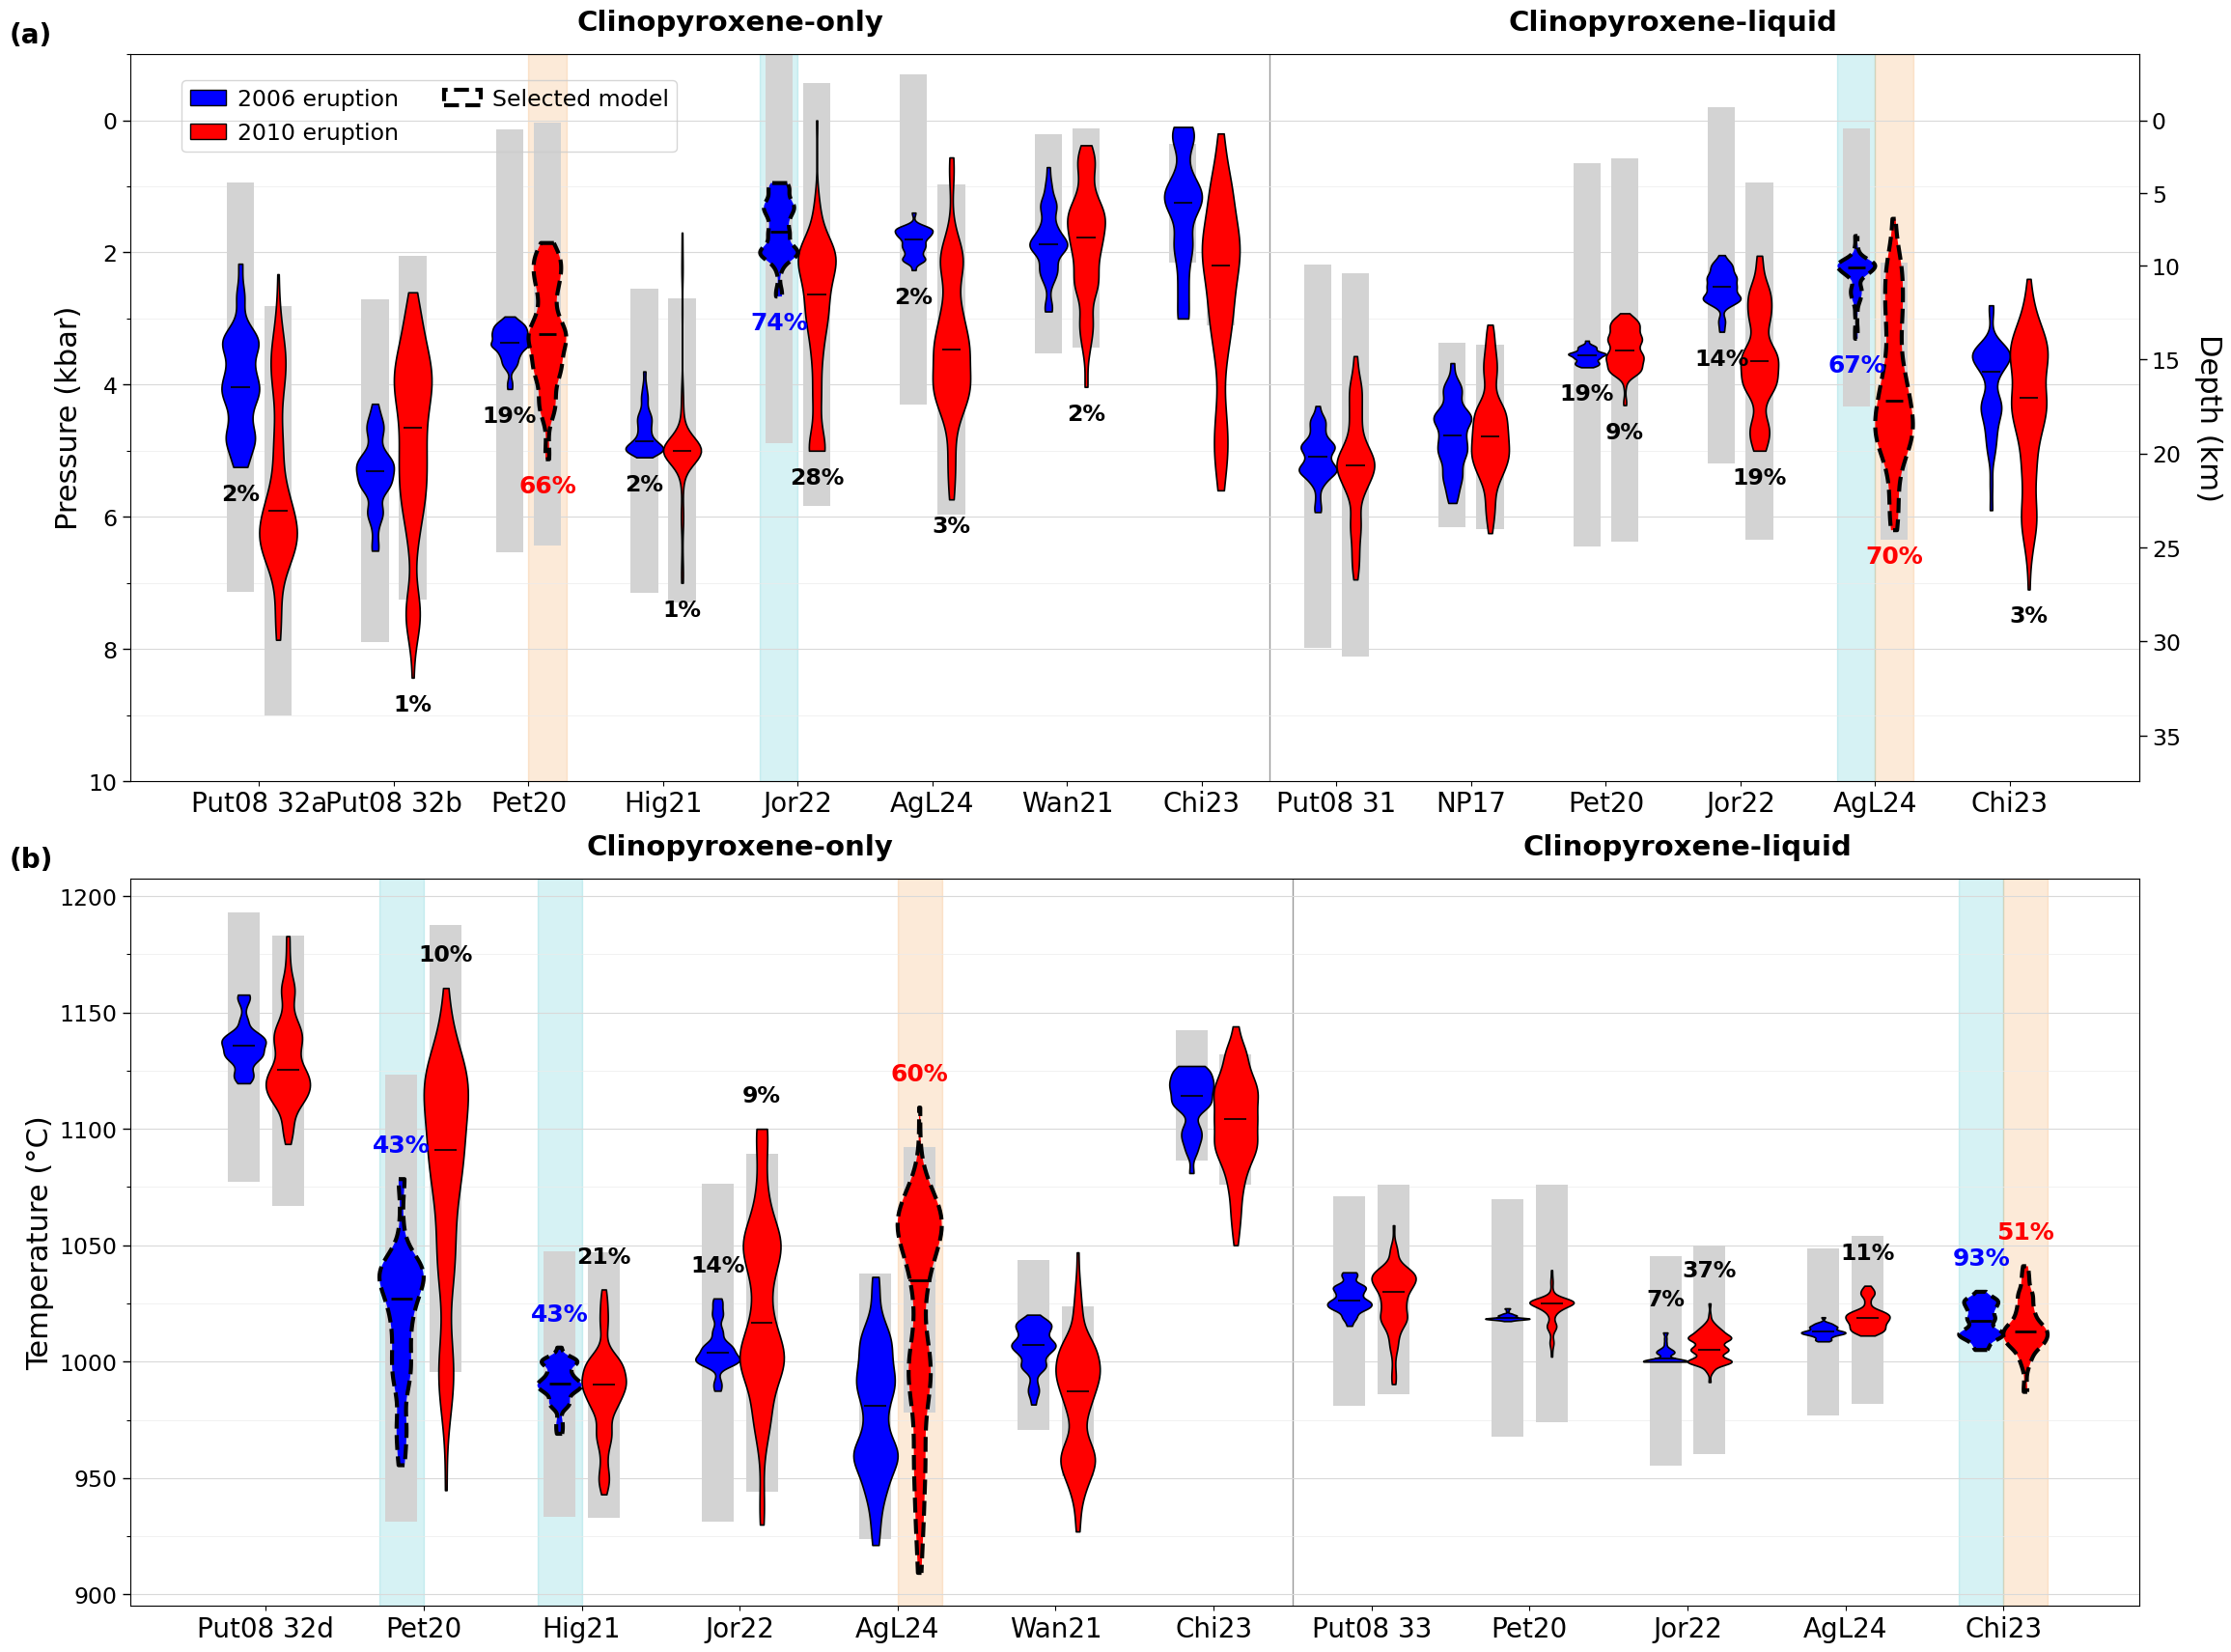

In [82]:
figs["this_study"][0]

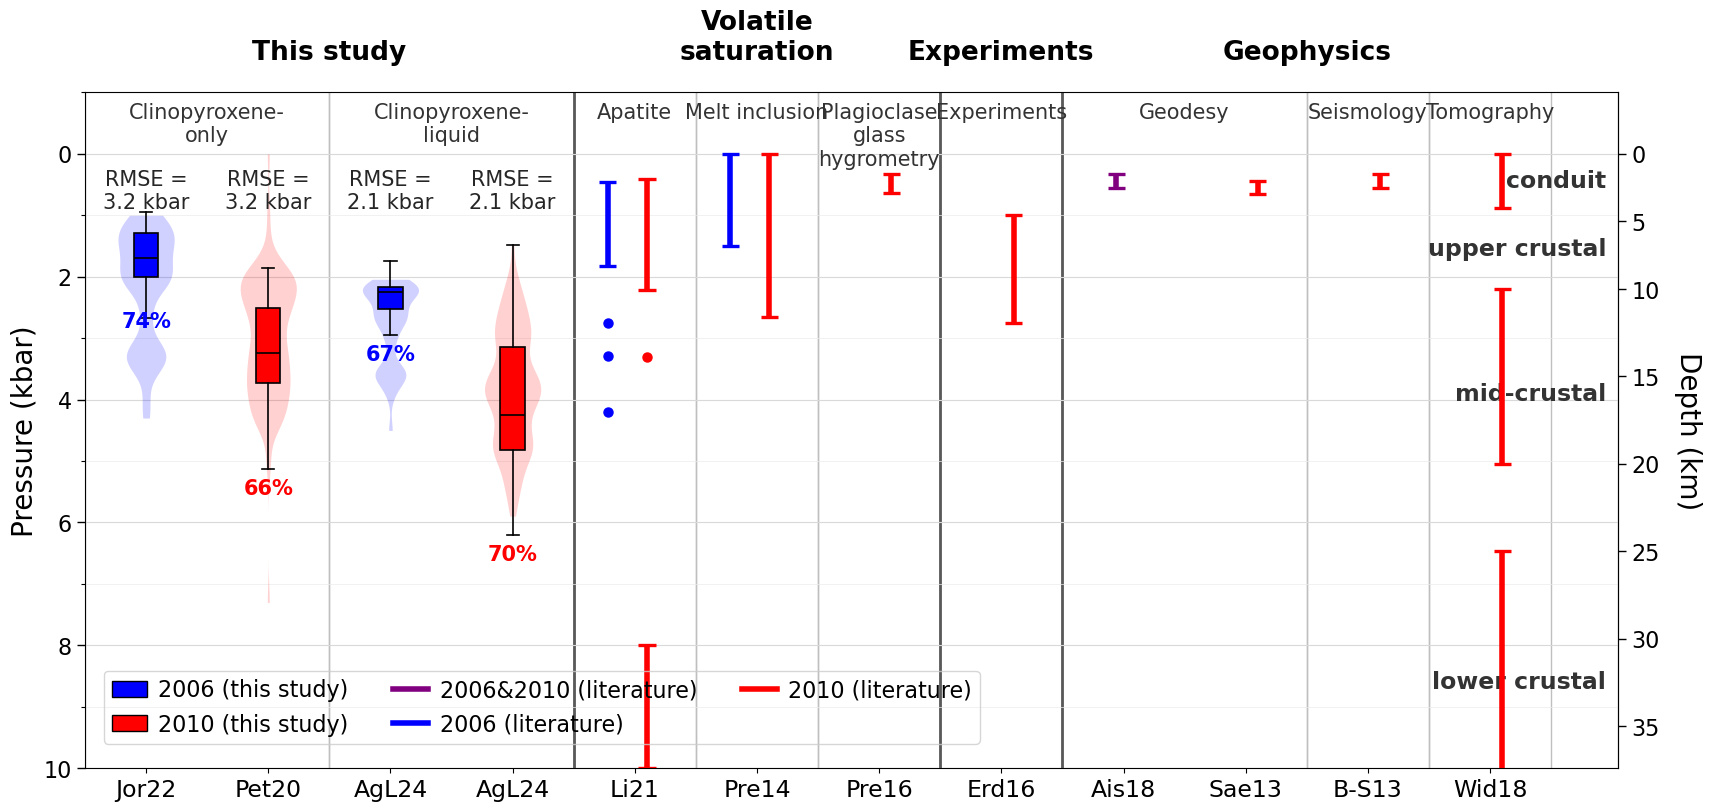

In [81]:
figs["literature_comparison"][0]

In [74]:

fig_s9, axes_s9 = plot_ranked_thermobarometry_literature_comparison(
    cpx_only,
    cpx_liq,
    pressure_columns={"cpx_only": P_cols_only, "cpx_liq": P_cols_liq},
    temperature_columns={"cpx_only": T_cols_only, "cpx_liq": T_cols_liq},
    pressure_literature=P_lit_raw,
    temperature_literature=T_lit_raw,
    pressure_model_pool=P_model_pool,
    temperature_model_pool=T_model_pool,
    liquid_results=liquid_results,
    pressure_ylim=(-1, 10),
    temperature_ylim = (800, 1150),
    densities_kg_m3=densities_kg_m3,
    layer_boundaries_km=layer_boundaries_km,
    literature_pressure_source="auto",
    figsize=(20.0, 17.0),
    use_model_abbreviations=True,
    pressure_reservoir_bands=MERAPI_2010_RESERVOIR_BANDS,
)
save_figure_pdf_png(
    fig_s9,
    IMAGES_DIR,
    "fig_s_Merapi_different_constraints_with_liquid_thermobarometer",
)

plt.show()


C:\Users\13493\AppData\Local\Temp\ipykernel_79512\2985565154.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [75]:
from aims4pt.visualization.thermobarometry_plot import (
    _apply_pressure_depth_axes,
    _build_ranked_thermobarometry_state,
    _build_this_study_columns_for_comparison,
)


def _finite_values(values):
    """Return finite values as a NumPy array."""
    arr = np.asarray(values, dtype=float)
    return arr[np.isfinite(arr)]


def _this_study_interval_rows(kind, this_cols):
    """Summarize Q1-Q3 and P16-P84 intervals for Fig. 9 this-study columns."""
    rows = []
    for col in this_cols:
        if "subcolumns" in col:
            series_items = [
                {
                    "label": f"{col['label']}\n{subcol['phase_name']}",
                    "type": col["type"],
                    "eruption": subcol["eruption"],
                    "fill": subcol["fill"],
                    "data": subcol["data"],
                }
                for subcol in col["subcolumns"]
            ]
        else:
            series_items = [col]

        for item in series_items:
            values = _finite_values(item["data"])
            if values.size == 0:
                continue
            p16, q1, median, q3, p84 = np.nanpercentile(values, [16, 25, 50, 75, 84])
            rows.append(
                {
                    "kind": kind,
                    "type": item["type"],
                    "eruption": item["eruption"],
                    "label": item["label"],
                    "color": item["fill"],
                    "n": values.size,
                    "p16": p16,
                    "q1": q1,
                    "median": median,
                    "q3": q3,
                    "p84": p84,
                    "q1_q3_width": q3 - q1,
                    "p16_p84_width": p84 - p16,
                    "width_delta": (p84 - p16) - (q3 - q1),
                    "width_ratio": (p84 - p16) / (q3 - q1) if q3 > q1 else np.nan,
                }
            )
    return rows


fig9_state = _build_ranked_thermobarometry_state(
    cpx_only,
    cpx_liq,
    pressure_columns={"cpx_only": P_cols_only, "cpx_liq": P_cols_liq},
    temperature_columns={"cpx_only": T_cols_only, "cpx_liq": T_cols_liq},
    pressure_model_pool=P_model_pool,
    temperature_model_pool=T_model_pool,
)

fig9_this_study_cols = {
    kind: _build_this_study_columns_for_comparison(
        kind,
        fig9_state,
        selection_threshold=50.0,
        use_model_abbreviations=True,
    )
    for kind in ("P", "T")
}

interval_rows = []
fig_q, axes_q = plt.subplots(2, 1, figsize=(20, 11), constrained_layout=True)

for ax, kind in zip(axes_q, ("P", "T")):
    rows = _this_study_interval_rows(kind, fig9_this_study_cols[kind])
    interval_rows.extend(rows)
    x = np.arange(1, len(rows) + 1)

    for xi, row in zip(x, rows):
        ax.vlines(xi - 0.09, row["q1"], row["q3"], color="0.25", lw=7, alpha=0.70, zorder=3)
        ax.hlines([row["q1"], row["q3"]], xi - 0.16, xi - 0.02, color="0.25", lw=1.8, zorder=3)
        ax.vlines(xi + 0.09, row["p16"], row["p84"], color=row["color"], lw=4, alpha=0.85, zorder=4)
        ax.hlines([row["p16"], row["p84"]], xi + 0.02, xi + 0.16, color=row["color"], lw=1.8, zorder=4)
        ax.plot(xi, row["median"], marker="o", ms=4, color="black", zorder=5)

    ax.set_xlim(0.4, len(rows) + 0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{row['label']}\n{row['eruption']}" for row in rows],
        rotation=0,
        ha="center",
        fontsize=9,
    )
    ax.grid(True, axis="y", color="0.88", linewidth=0.8)
    ax.set_title(f"Fig. 9 this study {kind}: Q1-Q3 vs P16-P84", fontsize=14)

    if kind == "P":
        _apply_pressure_depth_axes(
            ax,
            pressure_ylim=(-1, 10),
            densities_kg_m3=densities_kg_m3,
            layer_boundaries_km=layer_boundaries_km,
        )
    else:
        ax.set_ylabel("Temperature (deg C)")

axes_q[0].legend(
    handles=[
        Line2D([0], [0], color="0.25", lw=7, alpha=0.70, label="Q1-Q3"),
        Line2D([0], [0], color="black", lw=4, alpha=0.85, label="P16-P84"),
        Line2D([0], [0], marker="o", color="black", lw=0, label="median"),
    ],
    loc="upper right",
    frameon=True,
)

interval_comparison = pd.DataFrame(interval_rows)
display(
    interval_comparison[
        [
            "kind",
            "type",
            "eruption",
            "label",
            "n",
            "q1_q3_width",
            "p16_p84_width",
            "width_delta",
            "width_ratio",
        ]
    ].round(2)
)

plt.show()


,kind,type,eruption,label,n,q1_q3_width,p16_p84_width,width_delta,width_ratio
0,P,cpx_only,2006,Jor22,40,0.72,0.80,0.08,1.11
1,P,cpx_only,2010,Pet20,105,1.22,1.70,0.48,1.40
2,P,cpx_liq,2006,AgL24,38,0.36,0.50,0.13,1.37
3,P,cpx_liq,2010,AgL24,105,1.68,2.30,0.62,1.37
4,T,cpx_only,2006,Hig21,39,11.00,17.00,6.00,1.55
5,T,cpx_only,2006,Pet20,42,37.08,48.21,11.13,1.30
6,T,cpx_only,2010,AgL24,105,70.58,98.47,27.89,1.40
7,T,cpx_liq,2006,Chi23,42,11.75,15.44,3.69,1.31
8,T,cpx_liq,2010,Chi23,92,13.00,19.44,6.44,1.50


C:\Users\13493\AppData\Local\Temp\ipykernel_79512\1570988813.py:141: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
